In [1]:
from _SBMMatrix import *
from _FigureJiazeHelper import *
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
from scipy.sparse.linalg import eigs, eigsh
from scipy.linalg import eig
from _CommunityDetect import *
from EXPERIMENT_MINORITY import *
from spectralOperator import BetheHessian
from hypergraphx.viz import draw_communities
from matplotlib.colors import LinearSegmentedColormap
from EXPERIMENT_MinoritySameDegree import get_ps, read_exp
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

%load_ext autoreload
%autoreload 2

In [2]:
# Matplotlib settings

# plt.style.use('seaborn-whitegrid')
plt.rc('figure', figsize=(8, 5))
plt.rc('font', size=16)
plt.rc('font', family='sans-serif')
plt.rcParams['font.sans-serif'] = 'verdana'
plt.rcParams['lines.linewidth'] = 4
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.edgecolor'] = basic_line_color
plt.rcParams['xtick.color'] = basic_line_color
plt.rcParams['ytick.color'] = basic_line_color
plt.rcParams['axes.labelsize'] = 'large'
plt.rcParams['lines.markersize'] = 12

%config InlineBackend.figure_format = 'retina'

# Illustration Minority


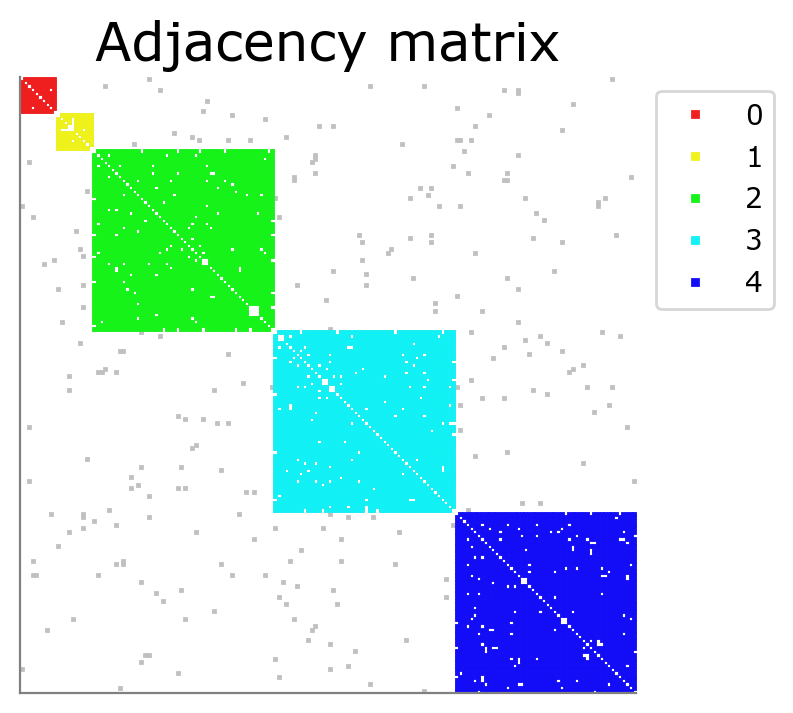

In [15]:
# Any Shape
sizes = [10, 10, 50, 50, 50]
pin = 0.95
pout1 = 0.01
pout2 = 0.01
ps = [[pin, pout1, pout2, pout2, pout2], [pout1, pin, pout2, pout2, pout2], [pout2, pout2, pin, pout1, pout1], [pout2, pout2, pout1, pin, pout1], [pout2, pout2, pout1, pout1, pin]]
sbm = SBMMatrix(sizes, ps)
d = np.sum(sbm.A) / np.sum(sizes)

fig = plt.figure(figsize=(4, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
c = gen_colors(start=colors_red[0], end=colors_blue[0], n=len(sbm.sizes))
plot_block_matrix(sbm.A.toarray(), partition_names=list(range(len(sbm.sizes))), partition_counts=sbm.sizes, colors=c)

In [22]:
def community_layout(graph, node_community, specific_scale=None):
    """生成社区布局，使得同一社区的节点靠近"""
    pos = {}
    # 每个社区分配一个中心
    num_communities = len(set(node_community.values()))
    angle_step = 2 * np.pi / num_communities
    community_centers = {
        i: (np.cos(i * angle_step), np.sin(i * angle_step))
        for i in range(num_communities)
    }

    # 为每个社区内的节点分配布局
    for community, center in community_centers.items():
        scale = specific_scale[community] if community in specific_scale else 0.2
        # 取出该社区的节点
        nodes = [n for n in graph if node_community[n] == community]
        # 使用 spring_layout 为社区内部布局
        subgraph = graph.subgraph(nodes)
        subgraph_pos = nx.spring_layout(subgraph, k=2, center=center, scale=scale)
        pos.update(subgraph_pos)
    return pos

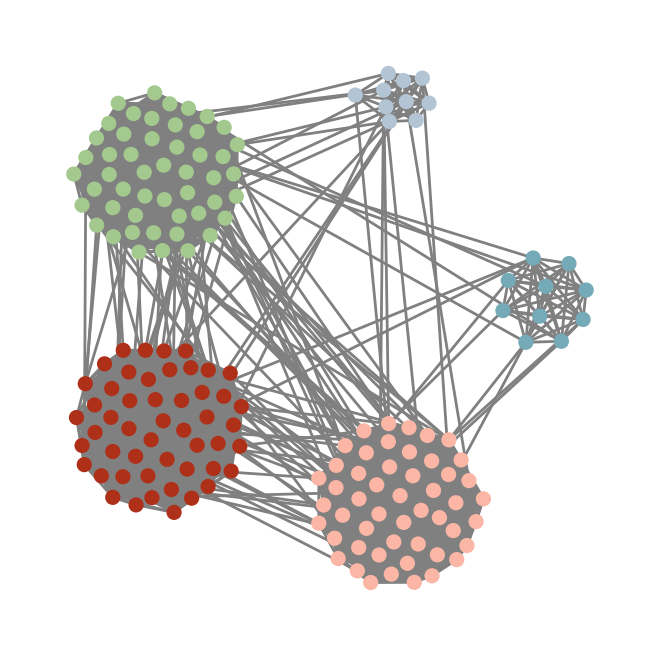

In [33]:
### Color
colors = ['#75AAB8', '#B3C4D4', '#A3C98E', '#AE3019', '#FCB6A5', '#B58C9A', '#DCCB59', '#CFC580', "#2900F2"]
n_bin = 5
color = [colors[0]] * sizes[0] + [colors[1]] * sizes[1] + [colors[2]] * sizes[2] + [colors[3]] * sizes[3] + [colors[4]] * sizes[4]
# Position
node_community = {i:sbm.groupId[i] for i in range(sbm.n)}
# pos = nx.spring_layout(proj_graph, k=1, iterations=100)
pos = community_layout(sbm.g, node_community, specific_scale={0:0.2, 1:0.2, 2:0.4, 3:0.4, 4:0.4})
fig = plt.figure(figsize=(4, 4))
widths = [4]
heights = [4]
spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
nx.draw(sbm.g, pos=pos, node_size=20, node_color=color, edge_color="gray")
save_path = "./_Figure/Minority/" + f"Illustration_Minority.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600)

# Consistent pout For different inference and order selection

In [70]:
n = 6000
d = 10
Z_s = 2
Z_b = 2
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
learnqby = None
givenTrueEpsilon = False
writeCM = False
additionId = "BH_learnq_NegEig"
fileID = 'amiExp25.2.12' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                               f'{"givenNumGroup" if givenNumGroup else ""}_' \
                               f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                               f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}__' \
                               f'_' \
                               f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
# exclude_rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([]))[25:].tolist() + [0]
exclude_rho = []
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho)
print(np.unique(plot_rhos))

[0.012 0.024 0.037 0.049 0.061 0.073 0.085 0.098 0.11  0.122 0.134 0.146
 0.159 0.171 0.183 0.195 0.207 0.22  0.232 0.244 0.256 0.268 0.28  0.293
 0.305 0.317 0.329 0.341 0.354 0.366 0.378 0.39  0.402 0.415 0.427 0.439
 0.451 0.463 0.476 0.488]


minz=0, maxz=1, cticks=[0, 1], clabel=['0', '1']
minz=1.0, maxz=4.3, cticks=[0.         0.30555556 0.61111111 0.91666667], clabel=['1', '2', '3', '4']


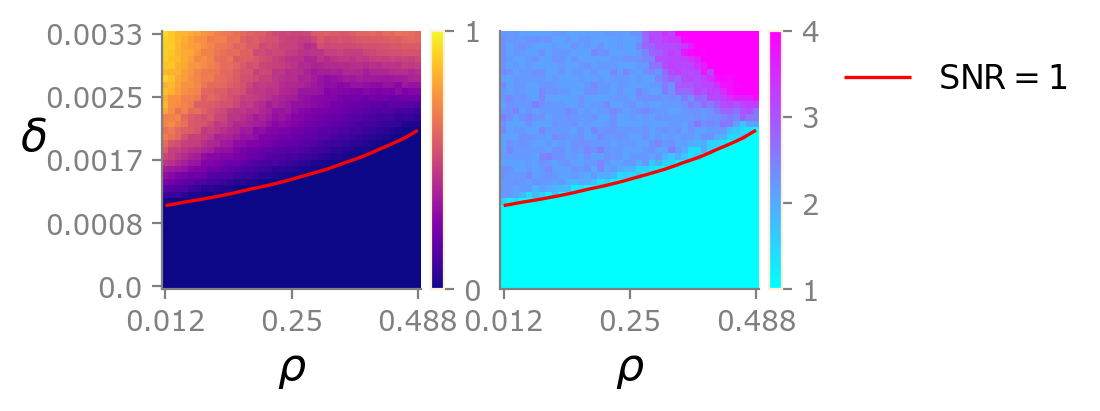

In [86]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 1.8))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
# cmap = cmap.with_extremes(bad="gray", under="gray", over="gray")
_ = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=0.5, title=r"", xlabel=r"$\rho$", ylabel=r"$\delta$", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=True, vmin=0, vmax=1, ytickprecision=4, cticks=[0, 1])
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=2.5, title="", xlabel=r'$\rho$', 
                                   ylabel=r'', cmap=cmap, ax=ax, fig=fig, vmax=4, ytickprecision=3, 
                                  set_yticks=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
lgd = fig.legend(handels, [r'$\rm SNR=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)

save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_" + f'{additionId}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=60, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [93]:
BP = False
learnqby = "MDL"
additionId = "BH_learnq_MDL"
fileID = 'amiExp25.2.12' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                               f'{"givenNumGroup" if givenNumGroup else ""}_' \
                               f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                               f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}__' \
                               f'_' \
                               f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
# exclude_rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([]))[25:].tolist() + [0]
exclude_rho = []
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho)
print(np.unique(plot_rhos))

[0.012 0.024 0.037 0.049 0.061 0.073 0.085 0.098 0.11  0.122 0.134 0.146
 0.159 0.171 0.183 0.195 0.207 0.22  0.232 0.244 0.256 0.268 0.28  0.293
 0.305 0.317 0.329 0.341 0.354 0.366 0.378 0.39  0.402 0.415 0.427 0.439
 0.451 0.463 0.476 0.488]


minz=0, maxz=1, cticks=[0, 1], clabel=['0', '1']
minz=1.0, maxz=3.0, cticks=[0.  0.5 1. ], clabel=['1', '2', '3']


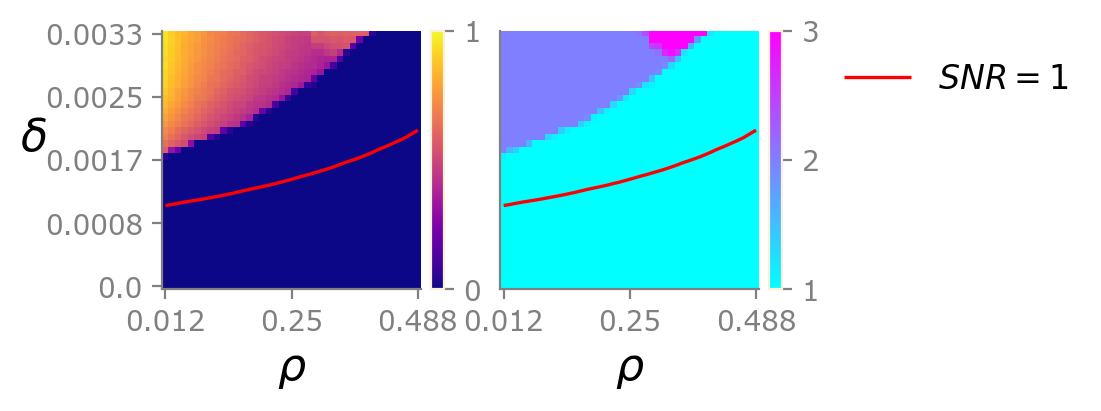

In [96]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 1.8))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
_ = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=0.5, title=r"", xlabel=r"$\rho$", ylabel=r"$\delta$", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=True, vmin=0, vmax=1, ytickprecision=4, cticks=[0, 1])
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=2, title="", xlabel=r'$\rho$', 
                                   ylabel=r'', cmap=cmap, ax=ax, fig=fig, vmax=3, ytickprecision=3, 
                                  set_yticks=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
lgd = fig.legend(handels, [r'$SNR=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)

save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_" + f'{additionId}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=60, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [97]:
BP = True
learnqby = None
additionId = "BP_learnq_NegEig"
fileID = 'amiExp25.2.13' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                               f'{"givenNumGroup" if givenNumGroup else ""}_' \
                               f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                               f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}__' \
                               f'_' \
                               f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
# exclude_rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([]))[25:].tolist() + [0]
exclude_rho = []
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho)
print(np.unique(plot_rhos))

[0.012 0.024 0.037 0.049 0.061 0.073 0.085 0.098 0.11  0.122 0.134 0.146
 0.159 0.171 0.183 0.195 0.207 0.22  0.232 0.244 0.256 0.268 0.28  0.293
 0.305 0.317 0.329 0.341 0.354 0.366 0.378 0.39  0.402 0.415 0.427 0.439
 0.451 0.463 0.476 0.488]


minz=0, maxz=1, cticks=[0, 1], clabel=['0', '1']
minz=1.0, maxz=4.3, cticks=[0.         0.30555556 0.61111111 0.91666667], clabel=['1', '2', '3', '4']


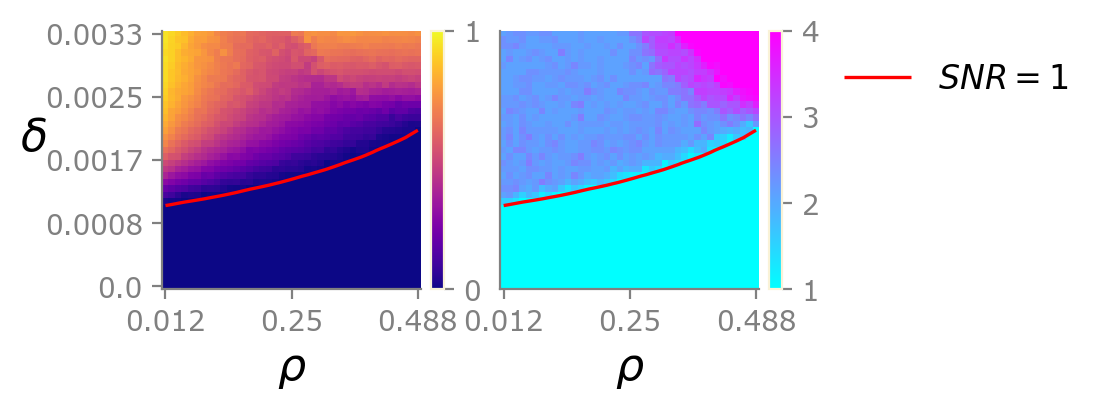

In [99]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 1.8))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
_ = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=0.5, title=r"", xlabel=r"$\rho$", ylabel=r"$\delta$", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=True, vmin=0, vmax=1, ytickprecision=4, cticks=[0, 1])
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=2.5, title="", xlabel=r'$\rho$', 
                                   ylabel=r'', cmap=cmap, ax=ax, fig=fig, vmax=4, ytickprecision=3, 
                                  set_yticks=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
lgd = fig.legend(handels, [r'$SNR=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)

save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_" + f'{additionId}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=60, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [100]:
BP = True
learnqby = "MDL"
additionId = "BP_learnq_MDL"
fileID = 'amiExp25.2.14' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                               f'{"givenNumGroup" if givenNumGroup else ""}_' \
                               f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                               f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}__' \
                               f'_' \
                               f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
# exclude_rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([]))[25:].tolist() + [0]
exclude_rho = []
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho)
print(np.unique(plot_rhos))

[0.012 0.024 0.037 0.049 0.061 0.073 0.085 0.098 0.11  0.122 0.134 0.146
 0.159 0.171 0.183 0.195 0.207 0.22  0.232 0.244 0.256 0.268 0.28  0.293
 0.305 0.317 0.329 0.341 0.354 0.366 0.378 0.39  0.402 0.415 0.427 0.439
 0.451 0.463 0.476 0.488]


minz=0, maxz=1, cticks=[0, 1], clabel=['0', '1']
minz=1.0, maxz=4.0, cticks=[0.         0.33333333 0.66666667 1.        ], clabel=['1', '2', '3', '4']


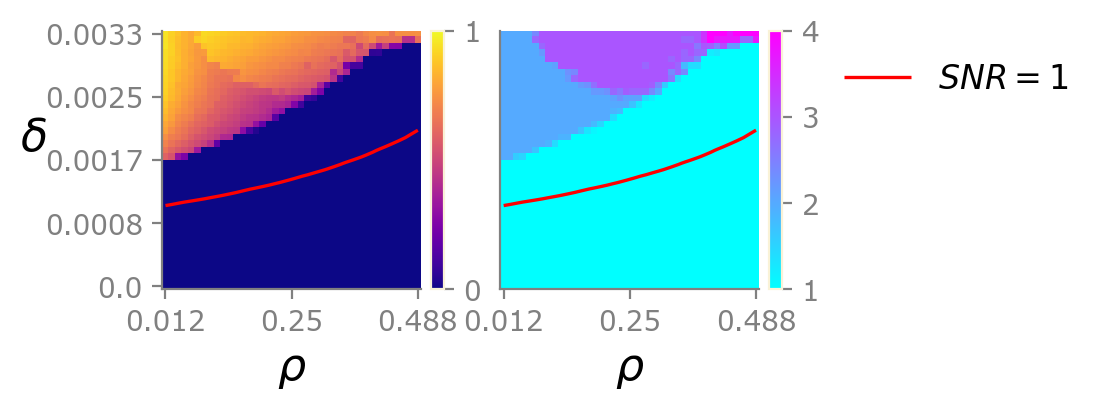

In [101]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 1.8))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
_ = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=0.5, title=r"", xlabel=r"$\rho$", ylabel=r"$\delta$", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=True, vmin=0, vmax=1, ytickprecision=4, cticks=[0, 1])
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=2.5, title="", xlabel=r'$\rho$', 
                                   ylabel=r'', cmap=cmap, ax=ax, fig=fig, vmax=4, ytickprecision=3, 
                                  set_yticks=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
lgd = fig.legend(handels, [r'$SNR=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)

save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_" + f'{additionId}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=60, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [102]:
BP = True
learnqby = "FE"
additionId = "BP_learnq_FE"
fileID = 'amiExp25.2.21' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                               f'{"givenNumGroup" if givenNumGroup else ""}_' \
                               f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                               f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}__' \
                               f'_' \
                               f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
# exclude_rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([]))[25:].tolist() + [0]
exclude_rho = []
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho)
print(np.unique(plot_rhos))

[0.012 0.024 0.037 0.049 0.061 0.073 0.085 0.098 0.11  0.122 0.134 0.146
 0.159 0.171 0.183 0.195 0.207 0.22  0.232 0.244 0.256 0.268 0.28  0.293
 0.305 0.317 0.329 0.341 0.354 0.366 0.378 0.39  0.402 0.415 0.427 0.439
 0.451 0.463 0.476 0.488]


minz=0, maxz=1, cticks=[0, 1], clabel=['0', '1']
minz=1.0, maxz=5.6, cticks=[0.         0.22115385 0.44230769 0.66346154 0.88461538], clabel=['1', '2', '3', '4', '5']


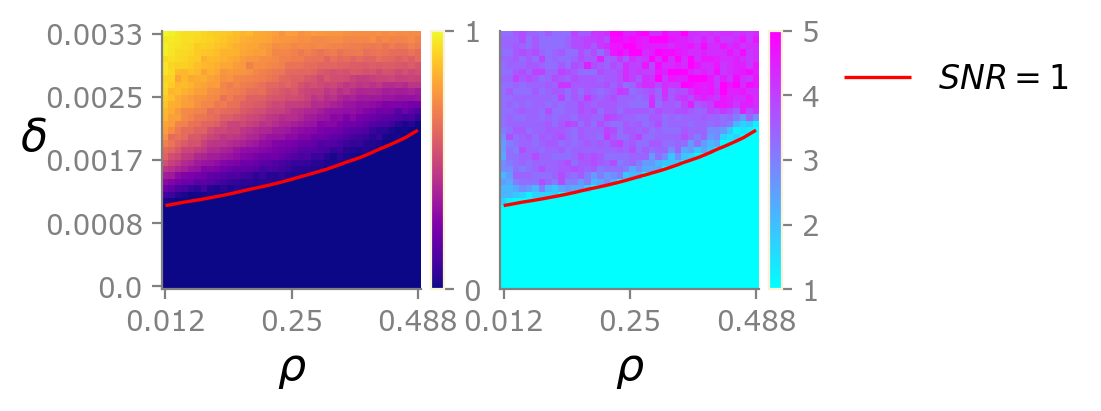

In [103]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 1.8))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
_ = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=0.5, title=r"", xlabel=r"$\rho$", ylabel=r"$\delta$", 
                min_z=0, max_z=1, cmap=cmap, ax=ax, fig=fig, return_gridz=False, set_xticks=True, vmin=0, vmax=1, ytickprecision=4, cticks=[0, 1])
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=3, title="", xlabel=r'$\rho$', 
                                   ylabel=r'', cmap=cmap, ax=ax, fig=fig, vmax=5, ytickprecision=3, 
                                  set_yticks=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
lgd = fig.legend(handels, [r'$SNR=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)

save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_" + f'{additionId}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=60, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [68]:
def show_matrix_value(matrix):
    fig = plt.figure(figsize=(12, 12))
    widths = [3]
    heights = [3]
    spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
    row = 0
    col = 0
    ax = fig.add_subplot(spec5[row, col])
    matrix = np.flip(matrix, axis=0)
    ax.matshow(matrix)
    shape = np.shape(matrix)
    for i in range(shape[0]):
        for j in range(shape[1]):
            c = matrix[i,j]
            ax.text(j, i, str(c), va='center', ha='center', fontsize=5)

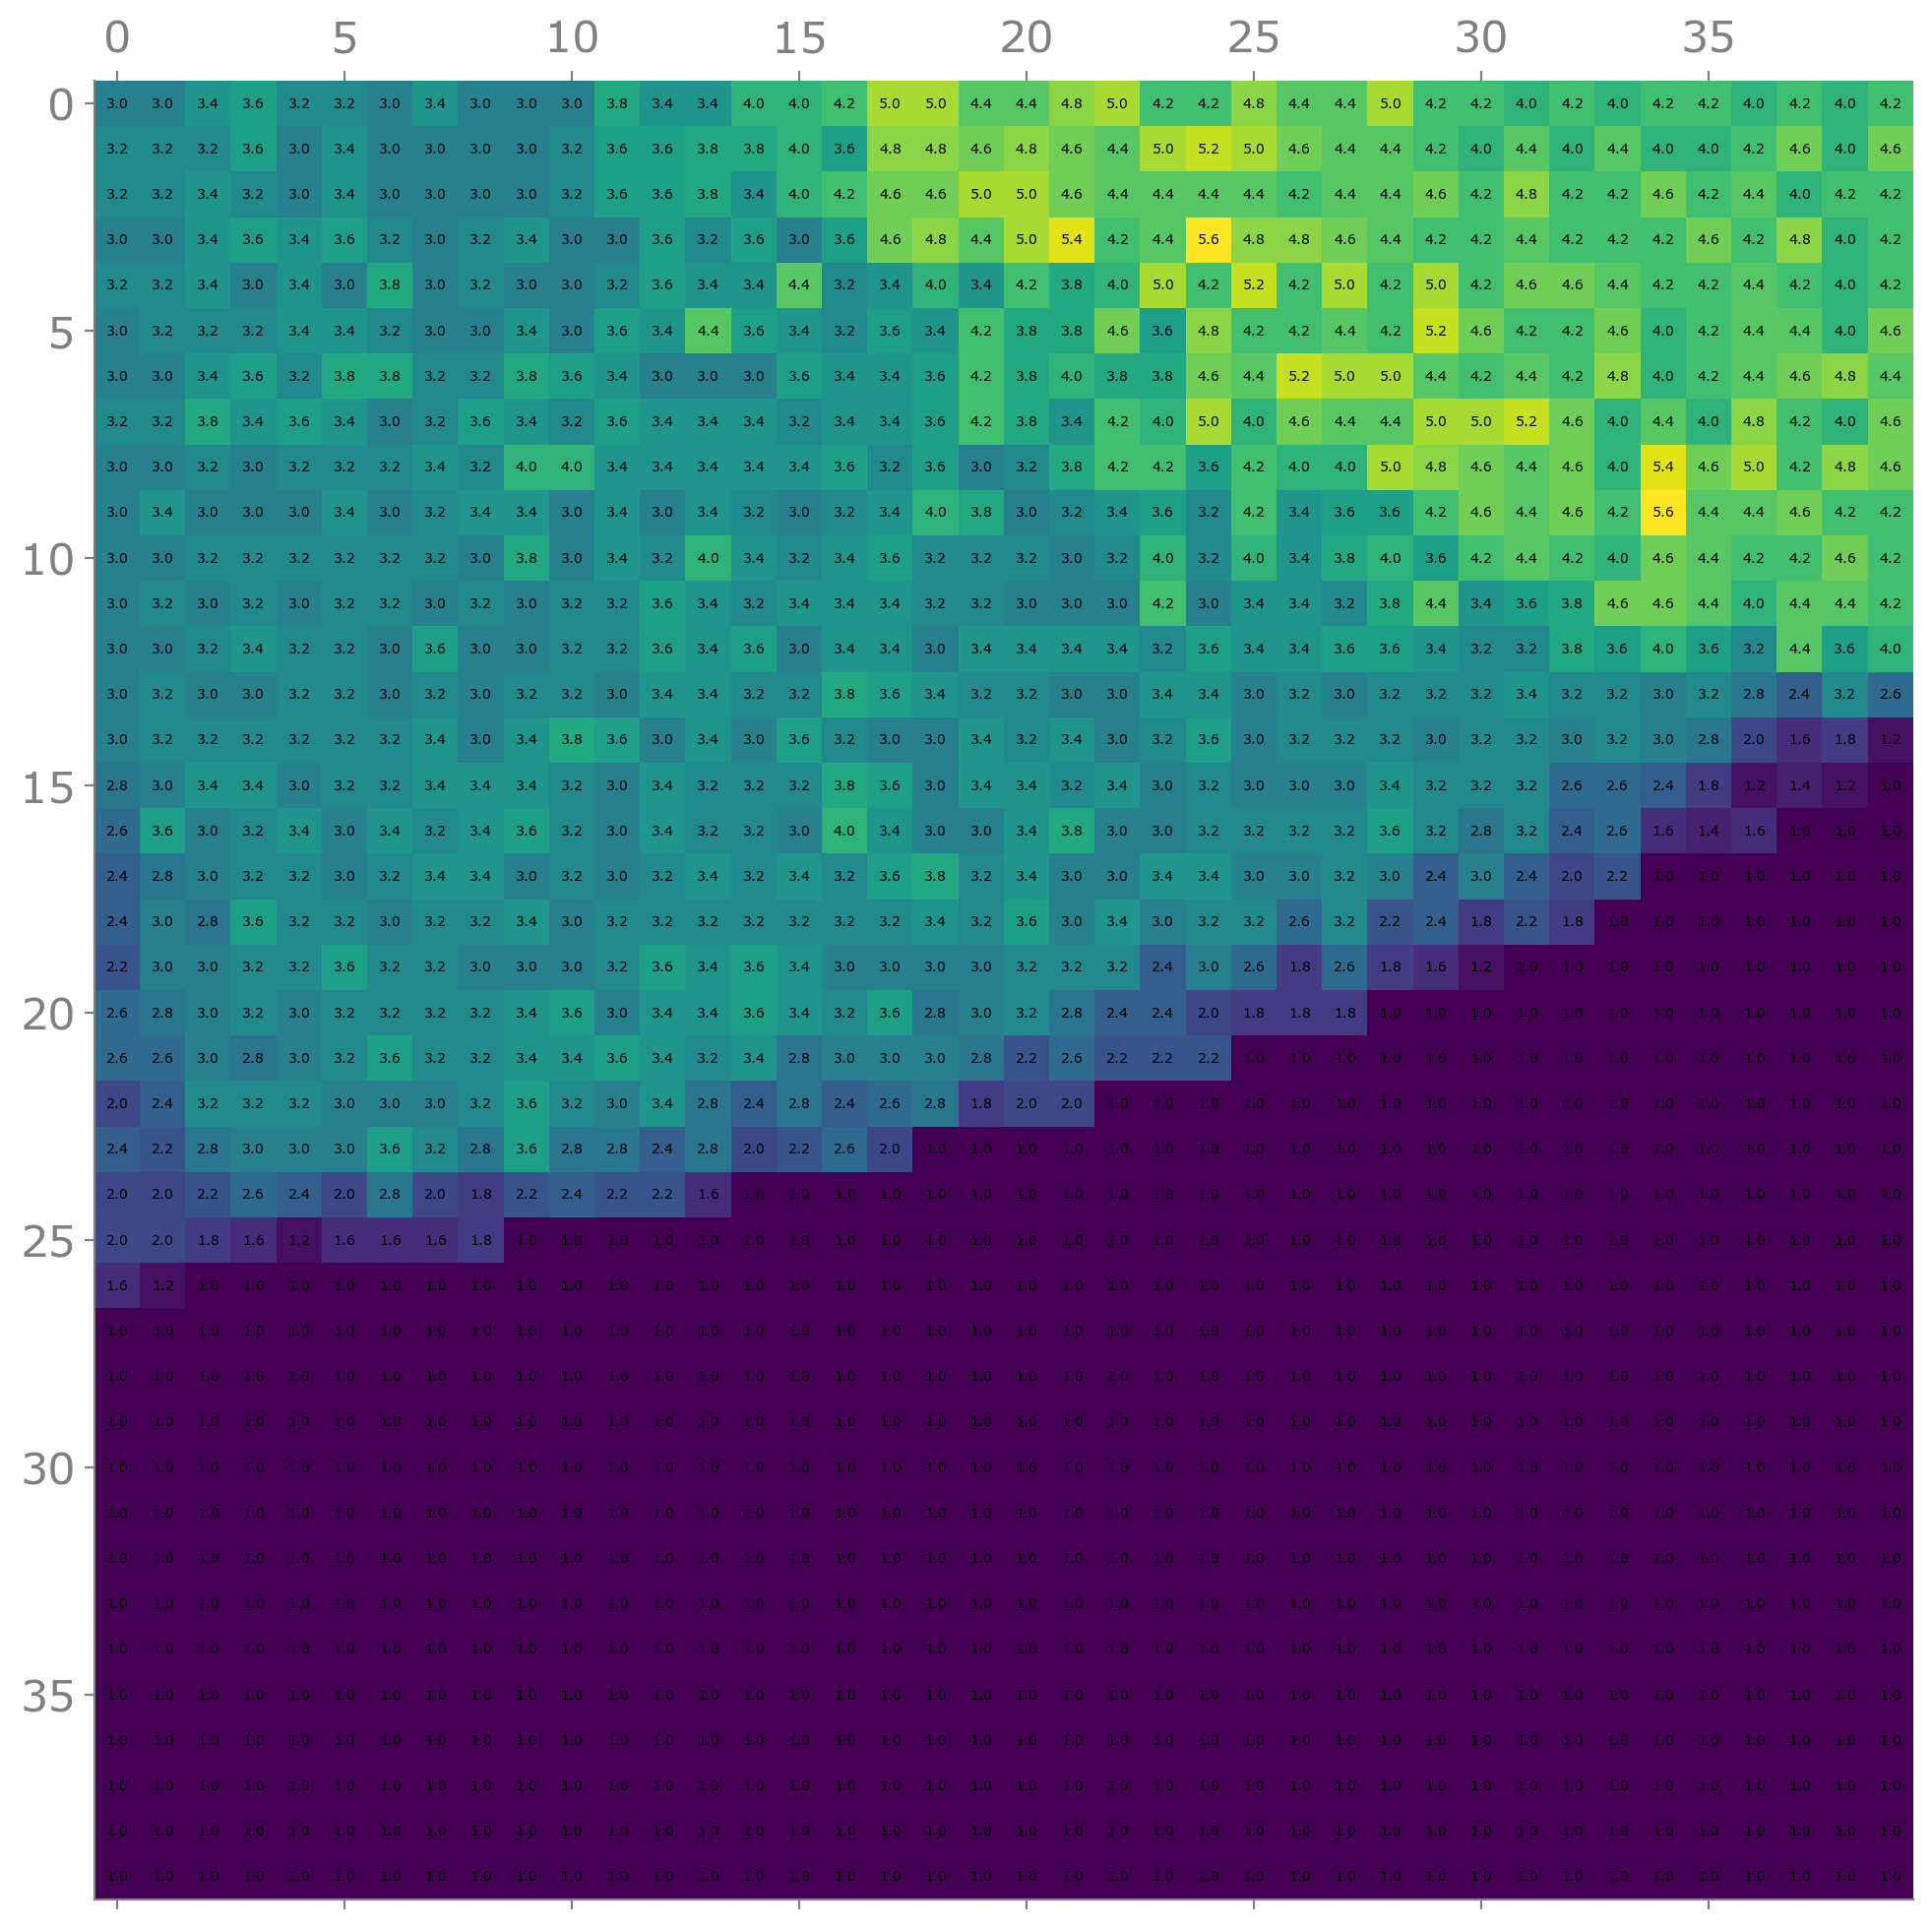

In [69]:
show_matrix_value(plot_subnumgroup)

# Consistent d for BP and BH

In [104]:
# For big n
n = 6000
d = 5
Z_s = 2
Z_b = 3
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
learnqby = None
givenTrueEpsilon = False
writeCM = False
additionId = "2ndType"
checkSNR = False
Type = 2
fileID = 'amiExp24.7.7' + f'_n={n}_Zs={Z_s}_Zb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                              f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                              f'{"CheckSNR" if checkSNR else ""}_' \
                              f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
exclude_rho = [0.4, 0.42, 0.44, 0.46, 0.48]
exclude_z = [0.00366, 0.00381, 0.00395, 0.0041]
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, exclude_z=exclude_z)
print(np.unique(plot_rhos))
print(np.min(sub_ami))

[0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28
 0.3  0.32 0.34 0.36 0.38]
-1.0


minz=0, maxz=0.8959130000000002, cticks=[0. 1.], clabel=['0', '1']
minz=1, maxz=5, cticks=[0.   0.25 0.5  0.75 1.  ], clabel=['1', '2', '3', '4', '5']


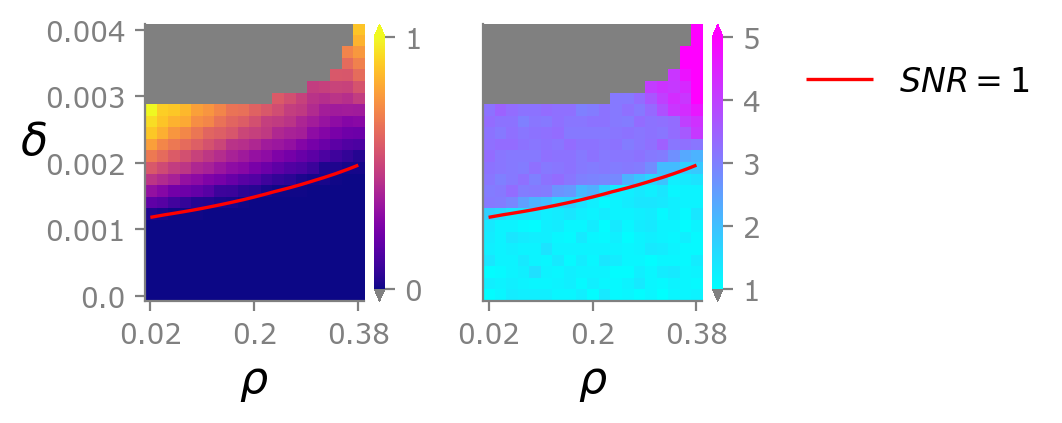

In [112]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 1.8))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
for i, zi in enumerate(sub_ami):
    if zi != -1 and zi<0:
        sub_ami[i] = 0  # close the minor negative gap close to 0
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, ytickprecision=3)


row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=5, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)


lgd = fig.legend(handels, [r'$SNR=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BH_samed" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [113]:
BP = True
learnqby = None
givenTrueEpsilon = False
writeCM = False
additionId = "2ndType_3or2decimal"
checkSNR = False
Type = 2
fileID = 'amiExp24.6.1' + f'_n={n}_Zs={Z_s}_Zb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                              f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                              f'{"CheckSNR" if checkSNR else ""}_' \
                              f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"

add_additionId = "2ndType_3or2decimal_10more"
add_fileId = 'amiExp24.6.3' + f'_n={n}_Zs={Z_s}_Zb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                              f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                              f'{"CheckSNR" if checkSNR else ""}_' \
                              f'{add_additionId}'
add_loadpath = ["./result/detectabilityWithMeta/" + add_fileId + ".txt"]
exclude_rho = [0.4, 0.42, 0.44, 0.46, 0.48]
exclude_z = [0.00366, 0.00381, 0.00395, 0.0041]
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, add_paths=add_loadpath, exclude_rho=exclude_rho, exclude_z=exclude_z)
print(np.unique(plot_rhos), np.unique(plot_zs), np.size(plot_zs))

Additional result adding...
[0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28
 0.3  0.32 0.34 0.36 0.38] [0.00015 0.00029 0.00044 0.00059 0.00073 0.00088 0.00103 0.00117 0.00132
 0.00146 0.00161 0.00176 0.0019  0.00205 0.0022  0.00234 0.00249 0.00264
 0.00278 0.00293 0.00308 0.00322 0.00337 0.00351] 456


minz=0, maxz=0.9376330000000002, cticks=[0. 1.], clabel=['0', '1']
minz=1, maxz=5, cticks=[0.   0.25 0.5  0.75 1.  ], clabel=['1', '2', '3', '4', '5']


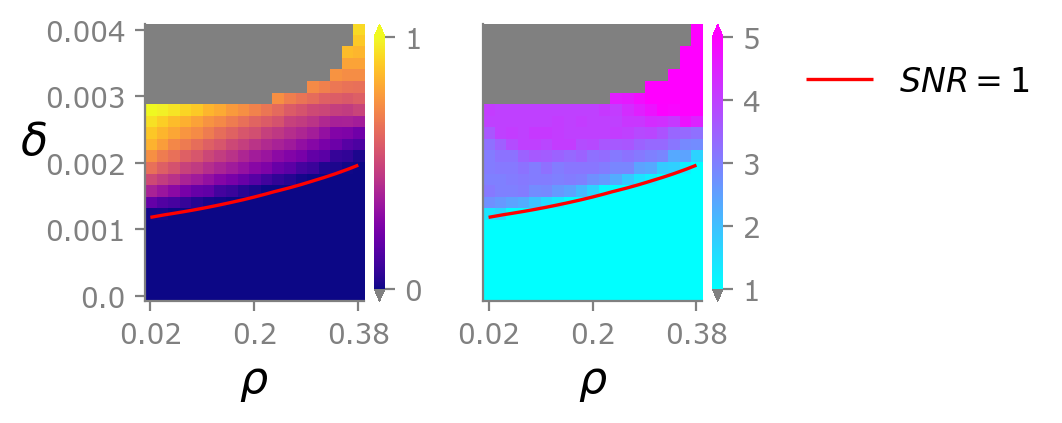

In [115]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 1.8))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
for i, zi in enumerate(sub_ami):
    if zi != -1 and zi<0:
        sub_ami[i] = 0  # close the minor negative gap close to 0
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, ytickprecision=3)


row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=5, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)


lgd = fig.legend(handels, [r'$SNR=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BP_samed" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

# Fit minority phase transition


In [3]:
# For big n
n = 6000
d = 50
Z_s = 1
Z_b = 1
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
fileID = 'amiExp24.1.17' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_fixsubparameter'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
# addfileId = 'amiExp24.1.10' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
#                               f'{"givenNumGroup" if givenNumGroup else ""}_' \
#                               f'{"DC" if DC else ""}_fixsubparameter_more'
# addload_path = "./result/detectabilityWithMeta/" + addfileId + ".txt"
exclude_rho = np.setdiff1d(np.around(np.linspace(0, 1, 51), 2), np.array([0, 1]))[24:]
print(exclude_rho)
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho)
print(np.unique(plot_rhos))

[0.5  0.52 0.54 0.56 0.58 0.6  0.62 0.64 0.66 0.68 0.7  0.72 0.74 0.76
 0.78 0.8  0.82 0.84 0.86 0.88 0.9  0.92 0.94 0.96 0.98]
[0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28
 0.3  0.32 0.34 0.36 0.38 0.4  0.42 0.44 0.46 0.48]


minz=0.0, maxz=1.0, cticks=[0. 1.], clabel=['0', '1']
minz=1.0, maxz=2.05, cticks=[0.  0.5], clabel=['1', '2']


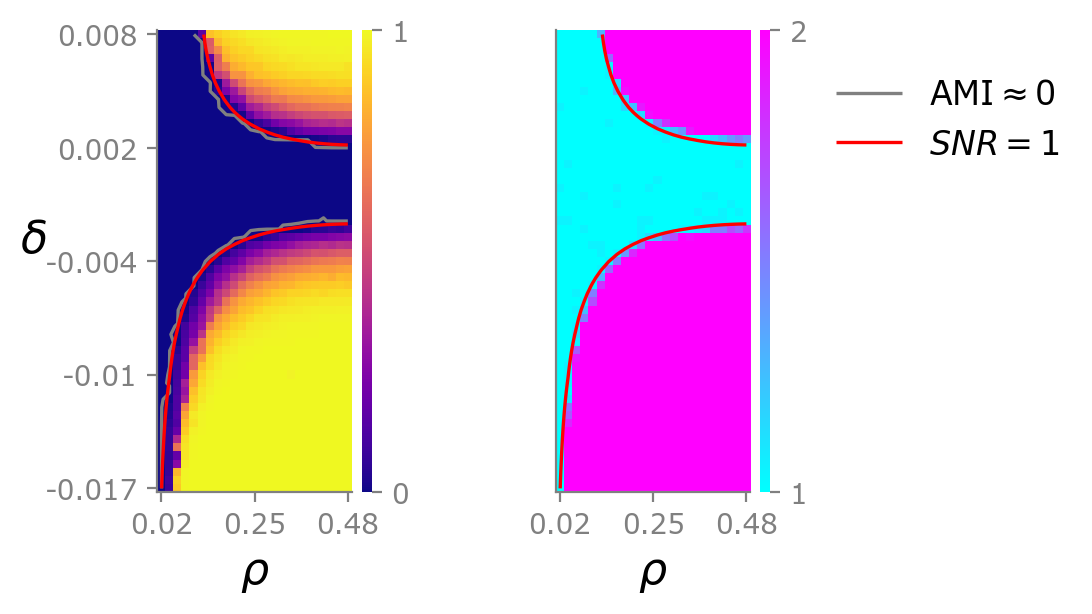

In [6]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 3))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', cmap=cmap, ax=ax, fig=fig, ytickprecision=3)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
handels += contour_data(plot_subami, ax, levels=[1e-3], fmt={1e-3: r'AMI$\simeq$0'}, color='gray', inline=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
# handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)
# handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=2, title="", xlabel=r'$\rho$', ylabel=r'', 
                                   cmap=cmap, ax=ax, fig=fig, vmax=2, ytickprecision=3, set_yticks=False)
# plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
# contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)
# contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
lgd = fig.legend(handels, [r'AMI$\approx$0', r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
plt.subplots_adjust(wspace=0.8)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_" + f'Z_s{Z_s}Z_b{Z_b}' + "_v1.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

# Consistent d BH phase transition

In [5]:
# For big n
n = 6000
d = 5
Z_s = 2
Z_b = 3
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
learnqby = None
givenTrueEpsilon = False
writeCM = False
additionId = "2ndType"
checkSNR = False
Type = 2
fileID = 'amiExp24.5.14' + f'_n={n}_Zs={Z_s}_Zb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                              f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                              f'{"CheckSNR" if checkSNR else ""}_' \
                              f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
exclude_rho = np.round(np.linspace(0.4, 0.49, 10), 3)
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho)
print(np.unique(plot_rhos))

[0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14
 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28
 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39]


minz=0, maxz=0.917902, cticks=[0. 1.], clabel=['0', '1']
minz=1, maxz=5, cticks=[0.   0.25 0.5  0.75 1.  ], clabel=['1', '2', '3', '4', '5']


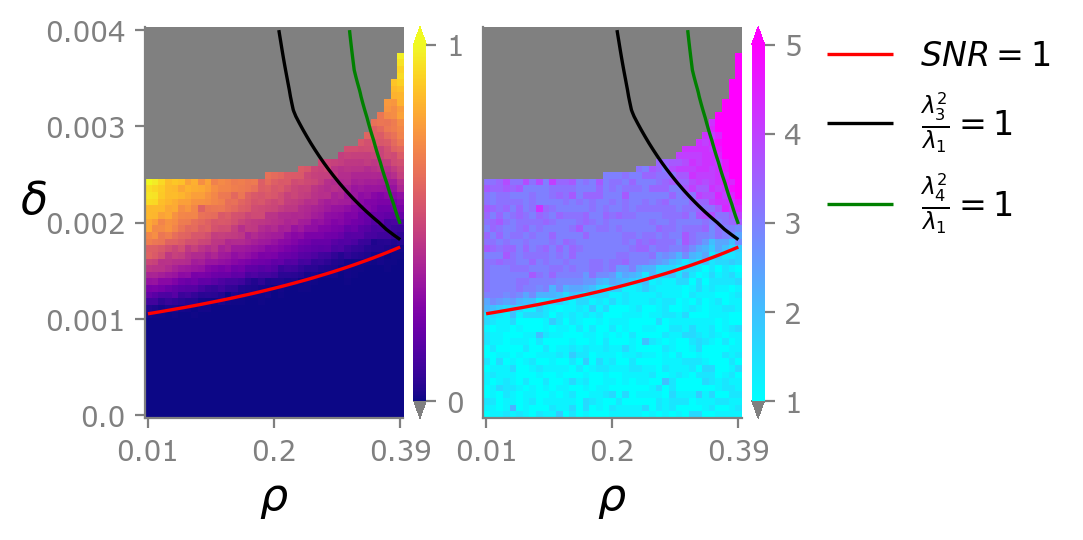

In [9]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 3))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
for i, zi in enumerate(sub_ami):
    if zi != -1 and zi<0:
        sub_ami[i] = 0  # close the minor negative gap close to 0
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, ytickprecision=3)

plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=5, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)


lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BH_samed" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

# Explore Setting n, d (Keep all figure in paper with same n, d)

In [3]:
def explore_lambdas(n=6000, d=5, Z_s=2, Z_b=3, rho_len=504, delta_len=502, consist_d=True, assortative=False, minority_s=True, num_lambda=4):
    q = Z_s + Z_b
    if minority_s:
        max_rho = Z_s/q
    rhos = np.setdiff1d(np.around(np.linspace(0, max_rho, rho_len), 6), np.array([0, 0.5, max_rho, 1]))
    min_delta, max_delta = None, None
    for r in rhos:
        for delta in np.setdiff1d(np.around(np.linspace(-1, 1, 10000), 6), np.array([])):
            if consist_d:
                _, pin, pout1, pout2 = get_ps(n, d, Z_s, Z_b, r, delta, Type=2)
                if 0 <= pin <= 1 and 0 <= pout1 <= 1 and 0 <= pout2 <= 1:
                    min_delta = delta if min_delta is None or delta < min_delta else min_delta
                    max_delta = delta if max_delta is None or delta > max_delta else max_delta
            else:
                pout = d / n - ((1-r)**2 / Z_b + r**2 / Z_s) * delta
                pin = pout + delta
                if 0 <= pin <= 1 and 0 <= pout <= 1:
                    min_delta = delta if min_delta is None or delta < min_delta else min_delta
                    max_delta = delta if max_delta is None or delta > max_delta else max_delta
    if assortative:
        min_delta = 0  # only consider assortative case
    
        
    deltas = np.setdiff1d(np.around(np.linspace(min_delta, max_delta, delta_len), 5), np.array([0]))
    print(f"max_rho={max_rho}, min_delta={min_delta}, max_delta={max_delta}")
    
    lambdas = np.zeros((np.size(deltas) * np.size(rhos), num_lambda))
    max_snr = 0
    expi = 0
    exp_samples = 0
    exp_samples_oversnr = 0
    for rho in rhos:
        for delta in deltas:
            if consist_d:
                ps, pin, pout1, pout2 = get_ps(n, d, Z_s, Z_b, rho, delta, Type)
                if pin < 0 or pin > 1 or pout1 < 0 or pout1 > 1 or pout2 < 0 or pout2 > 1:
                    # for delta let pin pout not in [0, 1], return (-1,0)
                    # print(f"rho={rho}, delta={delta}, pin={pin}, pout1={pout1}, pout2={pout2}, wrong")
                    lambdas[expi, :] = [1, np.inf, np.inf, np.inf]
                else:
                    P = np.diag([rho / Z_s] * Z_s + [(1 - rho) / Z_b] * Z_b)
                    Q = n * ps
                    lambdas[expi, :] = MetaSBM.get_lambdas_homoDegree(n, d, Z_s, Z_b, rho, delta, Type=Type)
                    snr = lambdas[expi, 1]**2/lambdas[expi, 0]
                    if snr is not np.inf and snr>max_snr:
                        max_snr = snr
                    exp_samples += 1
                    if snr > 1:
                        exp_samples_oversnr += 1
                    # print(f'rho={rho}, delta={delta}, lambdas_PQ={lambdas}')
            else:
                pout = d / n - ((1-rho)**2 / Z_b + rho**2 / Z_s) * delta
                pin = pout + delta
                ps = (pin - pout) * np.identity(q) + pout * np.ones((q, q))
                if pin < 0 or pin > 1 or pout < 0 or pout > 1:
                    lambdas[expi, :] = [1] + [np.inf] * (num_lambda-1)  # [1, np.inf, np.inf, np.inf]
                else:
                    P = np.diag([rho / Z_s] * Z_s + [(1 - rho) / Z_b] * Z_b)
                    Q = n * ps
                    lambdas[expi, :] = MetaSBM.get_lambdas(n, rho, Z_s, Z_b, pin, pout)
                    snr = lambdas[expi, 1]**2/lambdas[expi, 0]
                    if snr is not np.inf and snr>max_snr:
                        max_snr = snr
                    exp_samples += 1
                    if snr > 1:
                        exp_samples_oversnr += 1
            expi += 1
    print(f'Experiment samples {exp_samples}, with snr>1 samples {exp_samples_oversnr}')
    return rhos, deltas, lambdas, max_snr

max_rho=0.4, min_delta=0, max_delta=0.0037
Experiment samples 1929, with snr>1 samples 933
minz=0, maxz=4.807328404509109, cticks=[0.         0.33333333 0.66666667 1.        ], clabel=['0', '1', '2', '5']


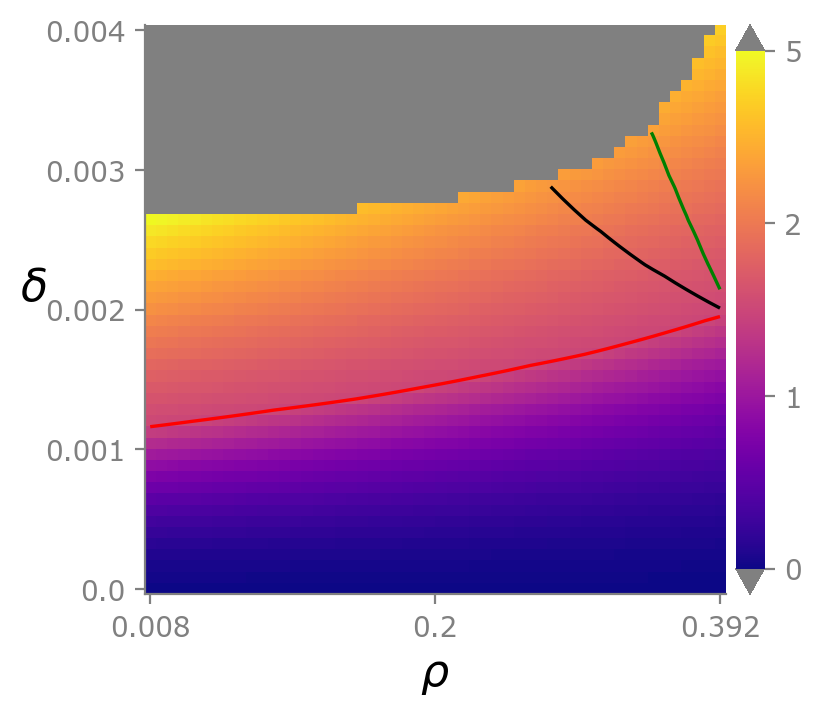

In [65]:
rhos, deltas, lambdas, max_snr = explore_lambdas(n=6000, d=5, Z_s=2, Z_b=3, rho_len=54, delta_len=52, assortative=True, consist_d=True)
plot_snrF_lambdas(rhos, deltas, lambdas, max_snr)

In [36]:
def plot_snrF_lambdas(rhos, deltas, lambdas, max_snr, have_l3=True, have_l4=True):
    fig = plt.figure(figsize=(4, 4))
    widths = [3]
    heights = [3]
    spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
    row = 0
    col = 0
    ax = fig.add_subplot(spec5[row, col])
    cmap = mpl.colormaps["plasma"]
    cmap.set_extremes(under='gray', over='gray', bad='gray')
    zcenter = 0.5
    plot_rhos = np.repeat(rhos, np.size(deltas))
    plot_zs = np.tile(deltas, np.size(rhos))
    # print(np.max(lambdas[:, 1]**2/lambdas[:, 0]))
    handels = []
    plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                                  min_z=0, max_z=max_snr, cmap=cmap, ax=ax, fig=fig, vmin=0, vmax=max_snr, ytickprecision=5, show_ext_color=True)
    handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
    if have_l3:
        plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
        handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
    if have_l4:
        plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
        handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

max_rho=0.5, min_delta=0, max_delta=0.0033
Experiment samples 2081, with snr>1 samples 1274
minz=0, maxz=6.002922539315466, cticks=[0.  0.2 0.4 0.6 0.8 1. ], clabel=['0', '0', '1', '2', '4', '6']


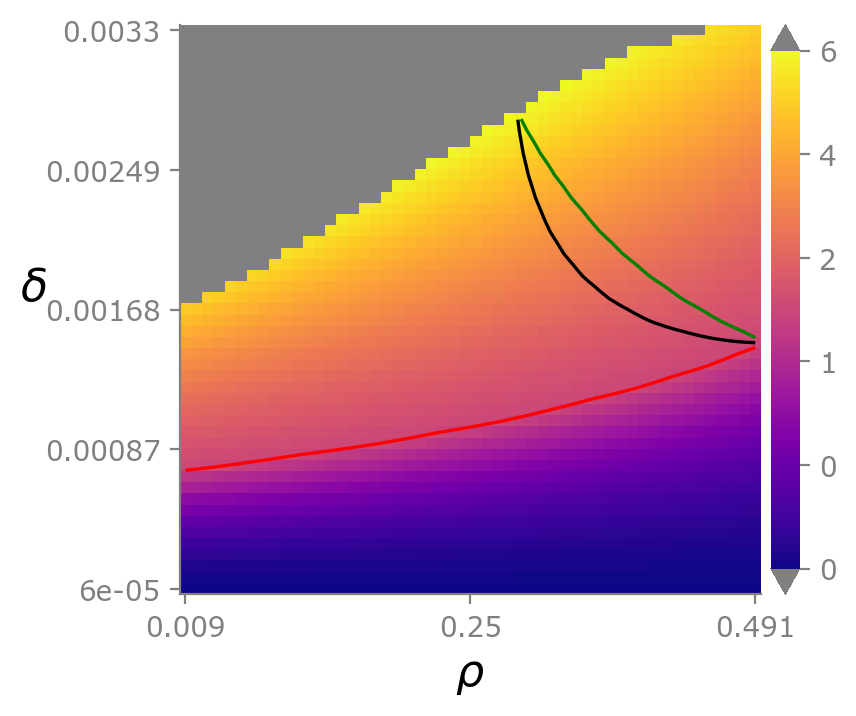

In [37]:
rhos, deltas, lambdas, max_snr = explore_lambdas(n=6000, d=5, Z_s=2, Z_b=2, rho_len=54, delta_len=52, assortative=True, consist_d=False)
plot_snrF_lambdas(rhos, deltas, lambdas, max_snr)

max_rho=0.5, min_delta=-0.016502, max_delta=0.033303
inf
minz=0, maxz=60.31741858413403, cticks=[0.         0.01694915 0.03389831 0.05084746 0.06779661 0.08474576
 0.10169492 0.11864407 0.13559322 0.15254237 0.16949153 0.18644068
 0.20338983 0.22033898 0.23728814 0.25423729 0.27118644 0.28813559
 0.30508475 0.3220339  0.33898305 0.3559322  0.37288136 0.38983051
 0.40677966 0.42372881 0.44067797 0.45762712 0.47457627 0.49152542
 0.50847458 0.52542373 0.54237288 0.55932203 0.57627119 0.59322034
 0.61016949 0.62711864 0.6440678  0.66101695 0.6779661  0.69491525
 0.71186441 0.72881356 0.74576271 0.76271186 0.77966102 0.79661017
 0.81355932 0.83050847 0.84745763 0.86440678 0.88135593 0.89830508
 0.91525424 0.93220339 0.94915254 0.96610169 0.98305085 1.        ], clabel=['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '1', '2', '4', '6', '8', '10', '12', '14', '16', '18', '20', '22', '24', '26', 

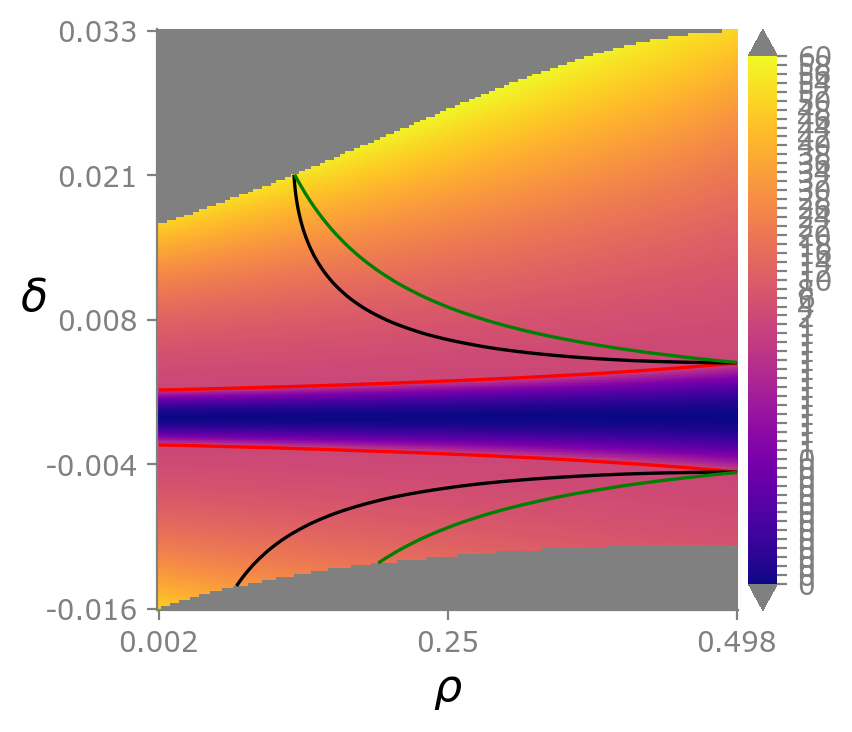

In [48]:
rhos, deltas, lambdas, max_snr = explore_lambdas(n=6000, d=50, Z_s=2, Z_b=2, rho_len=204, delta_len=202, assortative=False, consist_d=False)
plot_snrF_lambdas(rhos, deltas, lambdas, max_snr)

max_rho=0.4, min_delta=0, max_delta=0.0041
Experiment samples 2291, with snr>1 samples 1369
minz=0, maxz=5.722546952068971, cticks=[0.   0.25 0.5  0.75 1.  ], clabel=['0', '0', '1', '3', '6']


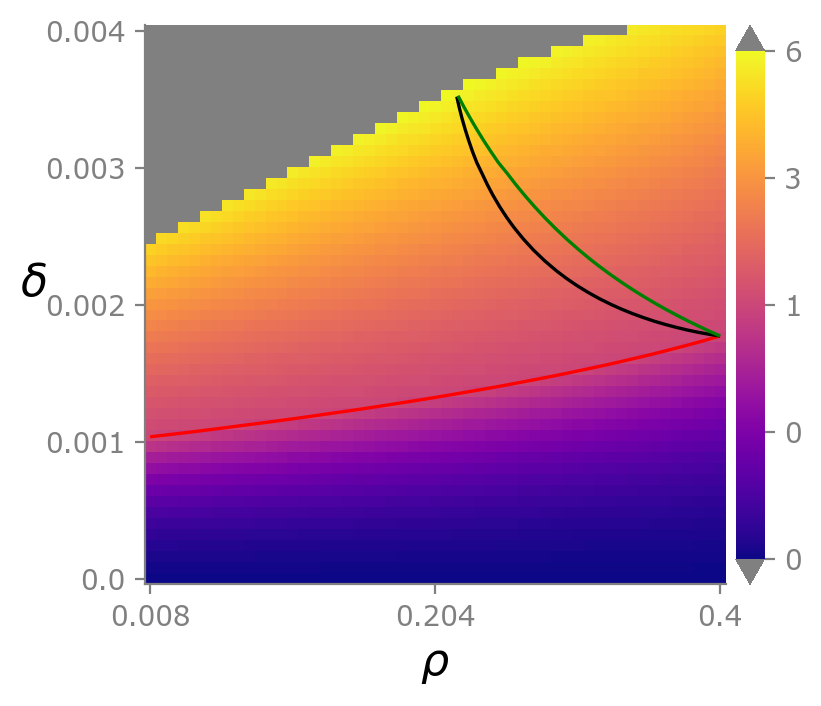

In [61]:
rhos, deltas, lambdas, max_snr = explore_lambdas(n=6000, d=5, Z_s=2, Z_b=3, rho_len=54, delta_len=52, assortative=True, consist_d=False)
plot_snrF_lambdas(rhos, deltas, lambdas, max_snr)

max_rho=0.6666666666666666, min_delta=-0.033303, max_delta=0.0023
Experiment samples 389, with snr>1 samples 189
minz=0, maxz=20.433282286541253, cticks=[0.         0.05263158 0.10526316 0.15789474 0.21052632 0.26315789
 0.31578947 0.36842105 0.42105263 0.47368421 0.52631579 0.57894737
 0.63157895 0.68421053 0.73684211 0.78947368 0.84210526 0.89473684
 0.94736842 1.        ], clabel=['0', '0', '0', '0', '0', '1', '1', '1', '1', '1', '2', '4', '6', '8', '10', '12', '14', '16', '18', '20']


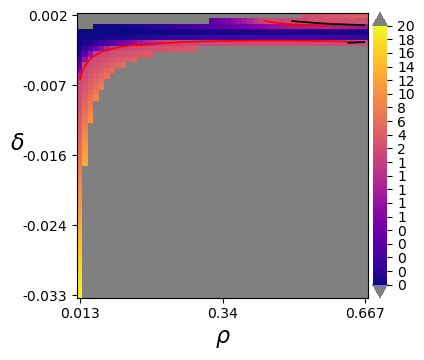

In [19]:
rhos, deltas, lambdas, max_snr = explore_lambdas(n=6000, d=5, Z_s=2, Z_b=1, rho_len=54, delta_len=52, assortative=False, consist_d=False, num_lambda=3)
plot_snrF_lambdas(rhos, deltas, lambdas, max_snr, have_l4=False)

max_rho=0.6666666666666666, min_delta=0, max_delta=0.0023
Experiment samples 1949, with snr>1 samples 472
minz=0, maxz=4.270947301952012, cticks=[0.         0.33333333 0.66666667 1.        ], clabel=['0', '1', '2', '4']


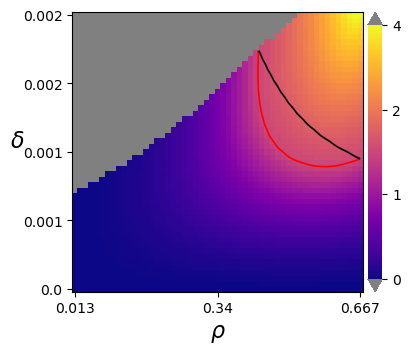

In [20]:
rhos, deltas, lambdas, max_snr = explore_lambdas(n=6000, d=5, Z_s=2, Z_b=1, rho_len=54, delta_len=52, assortative=True, consist_d=False, num_lambda=3)
plot_snrF_lambdas(rhos, deltas, lambdas, max_snr, have_l4=False)

max_rho=0.3333333333333333, min_delta=0, max_delta=0.0023
Experiment samples 2486, with snr>1 samples 1439
minz=0, maxz=5.551732155761383, cticks=[0.   0.25 0.5  0.75 1.  ], clabel=['0', '0', '1', '3', '6']


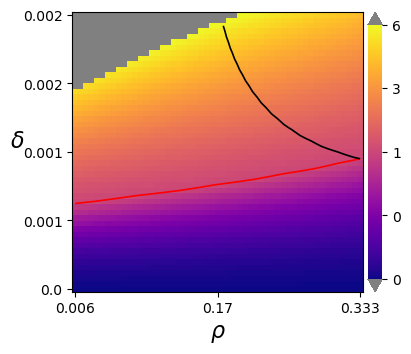

In [21]:
rhos, deltas, lambdas, max_snr = explore_lambdas(n=6000, d=5, Z_s=1, Z_b=2, rho_len=54, delta_len=52, assortative=True, consist_d=False, num_lambda=3)
plot_snrF_lambdas(rhos, deltas, lambdas, max_snr, have_l4=False)

max_rho=0.5, min_delta=0, max_delta=0.0015
Experiment samples 2239, with snr>1 samples 460
minz=0, maxz=4.010793505212539, cticks=[0.         0.33333333 0.66666667 1.        ], clabel=['0', '1', '2', '4']


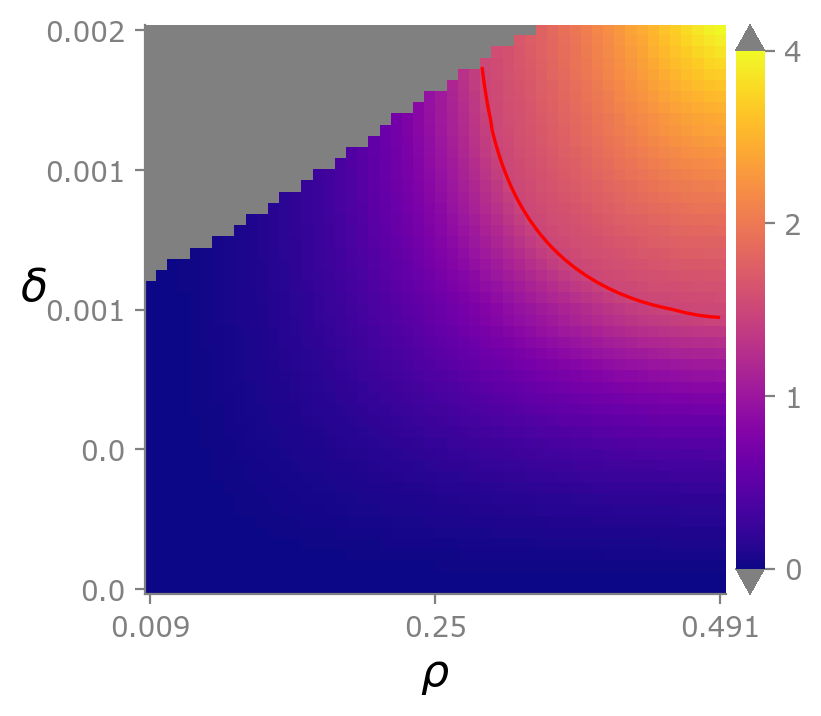

In [8]:
rhos, deltas, lambdas, max_snr = explore_lambdas(n=6000, d=5, Z_s=1, Z_b=1, rho_len=54, delta_len=52, assortative=True, consist_d=False, num_lambda=2)
plot_snrF_lambdas(rhos, deltas, lambdas, max_snr, have_l3=False, have_l4=False)

# Re Exp

In [3]:
def cm_for_network(delta, rho, n, d, Z_s, Z_b):
#     delta = 0.005
#     rho = 0.1
    pout = d / n - ((1-rho)**2 / Z_b + rho**2 / Z_s) * delta
    pin = pout + delta
    pin = 0 if pin < 1e-10 else pin
    pout = 0 if pout < 1e-10 else pout
    ps = (pin - pout) * np.identity(q) + pout * np.ones((q, q))
    n_f = int(n * (Z_s + Z_b) * (Z_b * rho + Z_s * (1 - rho)) / (Z_s * Z_b))
    rho_f = Z_b * rho / (Z_b * rho + Z_s * (1 - rho))
    n_fq = int(n_f / q)
    n_f = int(n_fq * q)
    sizes = [[n_fq] * Z_s, [n_fq] * Z_b]
    msbm = MetaSBM(n_f, rho_f, ps, sizes)
    A = msbm.sample()
    subA, subGroupId = msbm.filter(A, metaId=0)
    subTrueNumgroup = np.size(np.unique(subGroupId))
    subBHpartition, subBHNumgroup = CommunityDetect(subA).BetheHessian()
    print(f'True Sub Group Number is {subTrueNumgroup}')
    print(f'BH Sub Group Number is {subBHNumgroup}')
    confusionMatrix, _ = get_confusionmatrix(subGroupId, subBHpartition, subTrueNumgroup, subBHNumgroup)
    np.set_printoptions(suppress = True)
    print(f'rho is {rho}, AMI is {adjusted_mutual_info_score(subGroupId, subBHpartition)}, Confusion Matrix is\n {confusionMatrix}')
    fig = plt.figure(figsize=(4, 4))
    widths = [4]
    heights = [4]
    spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
    row = 0
    col = 0
    ax = fig.add_subplot(spec5[row, col])
    c = gen_colors(start=colors_red[0], end=colors_blue[0], n=6)
    _, indexes, counts = np.unique(subGroupId, return_index=True, return_counts=True)
    counts = counts[np.argsort(indexes)]
    plot_block_matrix(subA.toarray(), partition_names=list(range(6)), partition_counts=counts, colors=c, ms=0.01)
    return confusionMatrix

In [4]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [5]:
def plot_cm(confusionMatrix, rho, delta, fig=None, ax=None):
    subTrueNumgroup,subBHNumgroup = np.shape(confusionMatrix)
    rowsum = np.sum(confusionMatrix, axis=1)
    rowsum = rowsum.reshape(-1, 1)
    rowsum = np.repeat(rowsum, subBHNumgroup, axis=1)
    normConfusionMatrix = np.round(confusionMatrix / rowsum, 2)
    if fig is None and ax is None:
        fig = plt.figure(figsize=(3, 3))
        widths = [4]
        heights = [4]
        spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
        row = 0
        col = 0
        ax = fig.add_subplot(spec5[row, col])
#     cmap = mpl.colormaps["bwr_r"]
#     cmap = mpl.colormaps["RdYlBu"]
    cmap = mpl.colormaps["seismic_r"]
    cmap = truncate_colormap(cmap, 0.3, 0.7)
    im = ax.matshow(normConfusionMatrix, cmap=cmap, vmin=0, vmax=1)
    for i in range(subTrueNumgroup):
        for j in range(subBHNumgroup):
            c = normConfusionMatrix[i,j]
            ax.text(j, i, str(c), va='center', ha='center', fontsize=12)
#     ax.set_title(rf"$\rho={rho}, \delta={delta}$", fontsize=12)
    # ax.set_ylabel("True Community", rotation='horizontal', fontsize=20)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    return im

## 2,3 consistent d BH (low resolution)

In [13]:
# For big n
n = 6000
d = 5
Z_s = 2
Z_b = 3
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
learnqby = None
givenTrueEpsilon = False
writeCM = False
additionId = "2ndType"
checkSNR = False
Type = 2
fileID = 'amiExp24.7.7' + f'_n={n}_Zs={Z_s}_Zb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                              f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                              f'{"CheckSNR" if checkSNR else ""}_' \
                              f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
additionId = "2ndType_30more"
add_fileId = 'amiExp25.4.20' + f'_n={n}_Zs={Z_s}_Zb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                              f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                              f'{"CheckSNR" if checkSNR else ""}_' \
                              f'{additionId}'
add_paths = ["./result/detectabilityWithMeta/" + add_fileId + ".txt"]
# add_paths = []
exclude_rho = [0.4, 0.42, 0.44, 0.46, 0.48]
exclude_z = [0.00366, 0.00381, 0.00395, 0.0041, 0.00058, 0.00102, 0.00219, 0.00263, 0.00292, 0.00307, 0.00336]
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, 
                                                               exclude_rho=exclude_rho, exclude_z=exclude_z,
                                                               add_paths=add_paths)
print(np.unique(plot_rhos))
print(np.min(sub_ami))
print(np.unique(plot_zs))

Additional result adding...
[0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28
 0.3  0.32 0.34 0.36 0.38]
-1.0
[0.00015 0.00029 0.00044 0.00059 0.00073 0.00088 0.00103 0.00117 0.00132
 0.00146 0.00161 0.00176 0.0019  0.00205 0.0022  0.00234 0.00249 0.00264
 0.00278 0.00293 0.00308 0.00322 0.00337 0.00351]


minz=0, maxz=0.8855726000000003, cticks=[0. 1.], clabel=['0', '1']
minz=1, maxz=5, cticks=[0.   0.25 0.5  0.75 1.  ], clabel=['1', '2', '3', '4', '5']


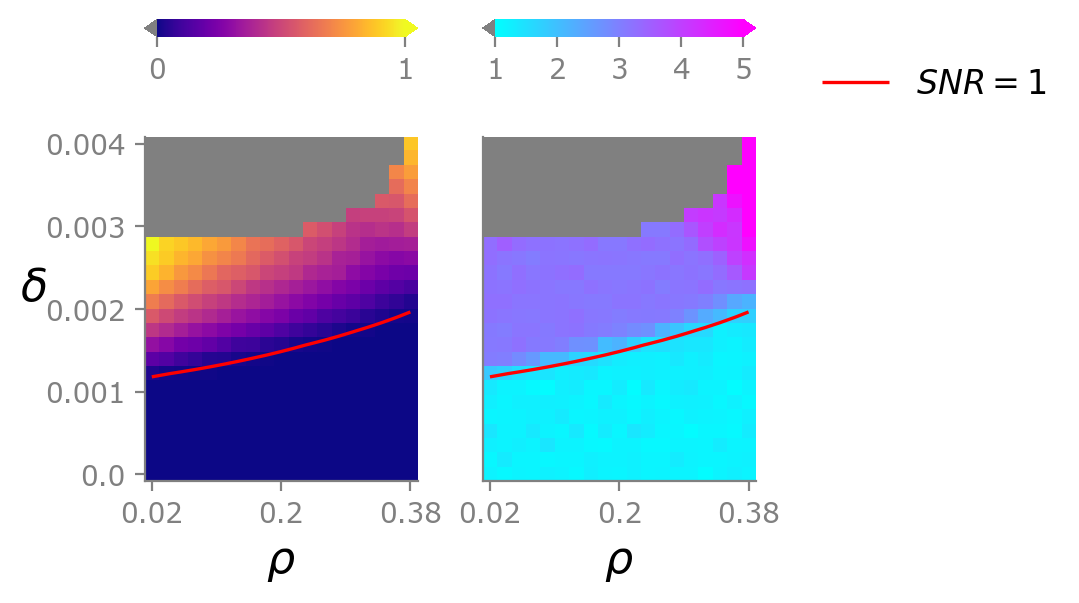

In [15]:
rhos, deltas = [0.02, 0.04, 0.06, 0.08, 0.1,  0.12, 0.14, 0.16, 0.18, 0.2,  0.22, 0.24, 0.26, 0.28,
 0.3, 0.32, 0.34, 0.36, 0.38], [0.00015, 0.00029, 0.00044, 0.00059, 0.00073, 0.00088, 0.00103, 0.00117, 0.00132,
 0.00146, 0.00161, 0.00176, 0.0019,  0.00205, 0.0022,  0.00234, 0.00249, 0.00264,
 0.00278, 0.00293, 0.00308, 0.00322, 0.00337, 0.00351]
# rhos, deltas = [0.02, 0.04, 0.06, 0.08, 0.1,  0.12, 0.14, 0.16, 0.18, 0.2,  0.22, 0.24, 0.26, 0.28,
#  0.3, 0.32, 0.34, 0.36, 0.38], [0.00015,0.00029, 0.00044, 0.00058, 0.00059, 0.00073, 0.00088, 0.00102, 0.00103,
#  0.00117, 0.00132, 0.00146, 0.00161, 0.00176, 0.0019,  0.00205, 0.00219, 0.0022,
#  0.00234, 0.00249, 0.00263, 0.00264, 0.00278, 0.00292, 0.00293, 0.00307, 0.00308,
#  0.00322, 0.00336, 0.00337, 0.00351]
# print(rhos)
# print(deltas)
i = 0
for _rho in rhos:
    for _delta in deltas:
        _, pin, pout1, pout2 = get_ps(n, d, Z_s, Z_b, _rho, _delta, Type=2)
        if pin < 0 or pin > 1 or pout1 < 0 or pout1 > 1 or pout2 < 0 or pout2 > 1:
            sub_ami[i] = -1
            sub_num_group[i] = -1
            lambdas[i] = [1, np.inf, np.inf, np.inf]
        # else:
        #     l = MetaSBM.get_lambdas(n, _rho, Z_s, Z_b, pin, pout)
        #     snr = l[1]**2/l[0]
        #     if snr < 1:
        #         sub_ami[i] = 0
        #         sub_num_group[i] = 1
        i += 1
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 3))
# fig = plt.figure(figsize=(16, 16))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
for i, zi in enumerate(sub_ami):
    if zi != -1 and zi<0:
        sub_ami[i] = 0  # close the minor negative gap close to 0
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=3, show_colorbar=True, show_ext_color=True, top_cbar=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, ytickprecision=3)

# plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
# handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=5, ytickprecision=3, show_colorbar=True, show_ext_color=True, top_cbar=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
# plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
# contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)


lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BH_samed" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + "_v1.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

## 2,3 consistent d BP (low resolution)

In [44]:
# For big n
n = 6000
d = 5
Z_s = 2
Z_b = 3
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = True
learnqby = None
givenTrueEpsilon = False
writeCM = False
additionId = "2ndType_3or2decimal"
checkSNR = False
Type = 2
fileID = 'amiExp24.6.1' + f'_n={n}_Zs={Z_s}_Zb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                              f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                              f'{"CheckSNR" if checkSNR else ""}_' \
                              f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"

add_additionId = "2ndType_3or2decimal_10more"
add_fileId = 'amiExp24.6.3' + f'_n={n}_Zs={Z_s}_Zb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                              f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                              f'{"CheckSNR" if checkSNR else ""}_' \
                              f'{add_additionId}'
add_loadpath = ["./result/detectabilityWithMeta/" + add_fileId + ".txt"]
exclude_rho = [0.4, 0.42, 0.44, 0.46, 0.48]
exclude_z = [0.00366, 0.00381, 0.00395, 0.0041]
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, add_paths=add_loadpath, exclude_rho=exclude_rho, exclude_z=exclude_z)
print(np.unique(plot_rhos), np.unique(plot_zs), np.size(plot_zs))

Additional result adding...
[0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28
 0.3  0.32 0.34 0.36 0.38] [0.00015 0.00029 0.00044 0.00059 0.00073 0.00088 0.00103 0.00117 0.00132
 0.00146 0.00161 0.00176 0.0019  0.00205 0.0022  0.00234 0.00249 0.00264
 0.00278 0.00293 0.00308 0.00322 0.00337 0.00351] 456


D:\Work\PhD\_code\_nodeclassification\_FigureJiazeHelper.py:141: RuntimeWarning: invalid value encountered in scalar divide
  norm_z[i] = (z[i] - z_center) / (maxz - z_center) * 0.5 + 0.5


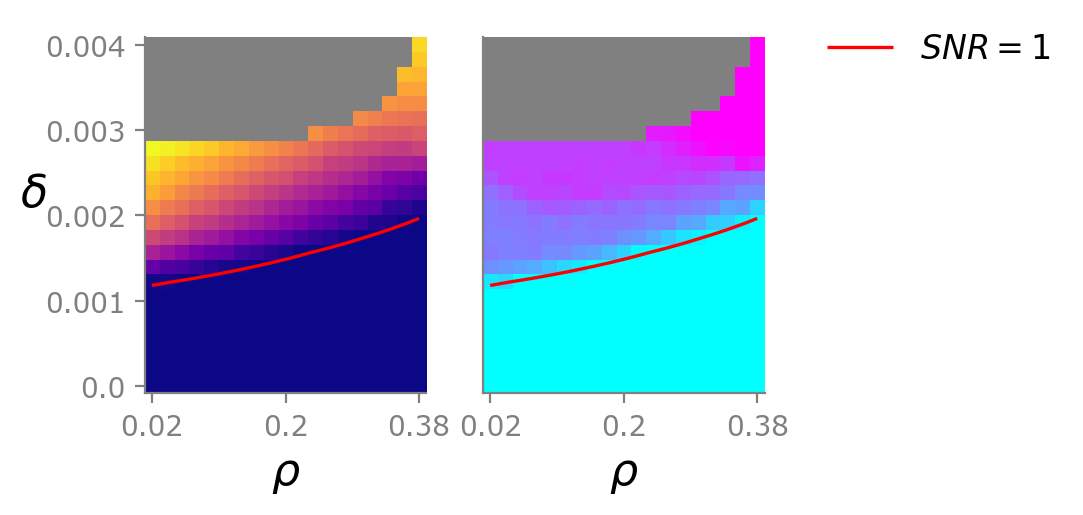

In [45]:
rhos, deltas = [0.02, 0.04, 0.06, 0.08, 0.1,  0.12, 0.14, 0.16, 0.18, 0.2,  0.22, 0.24, 0.26, 0.28,
 0.3, 0.32, 0.34, 0.36, 0.38], [0.00015, 0.00029, 0.00044, 0.00059, 0.00073, 0.00088, 0.00103, 0.00117, 0.00132,
 0.00146, 0.00161, 0.00176, 0.0019,  0.00205, 0.0022,  0.00234, 0.00249, 0.00264,
 0.00278, 0.00293, 0.00308, 0.00322, 0.00337, 0.00351]
# print(rhos)
# print(deltas)
i = 0
for _rho in rhos:
    for _delta in deltas:
        _, pin, pout1, pout2 = get_ps(n, d, Z_s, Z_b, _rho, _delta, Type=2)
        if pin < 0 or pin > 1 or pout1 < 0 or pout1 > 1 or pout2 < 0 or pout2 > 1:
            sub_ami[i] = -1
            sub_num_group[i] = -1
            lambdas[i] = [1, np.inf, np.inf, np.inf]
        # else:
        #     l = MetaSBM.get_lambdas(n, _rho, Z_s, Z_b, pin, pout)
        #     snr = l[1]**2/l[0]
        #     if snr < 1:
        #         sub_ami[i] = 0
        #         sub_num_group[i] = 1
        i += 1
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 3))
# fig = plt.figure(figsize=(16, 16))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
for i, zi in enumerate(sub_ami):
    if zi != -1 and zi<0:
        sub_ami[i] = 0  # close the minor negative gap close to 0
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=3, show_colorbar=False, show_ext_color=True, top_cbar=False)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, ytickprecision=3)

# plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
# handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=5, ytickprecision=3, show_colorbar=False, show_ext_color=True, top_cbar=False)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
# plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
# contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)


lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BP_samed" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + "_v1.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

## 2,3 consistent d BH (high resolution)

In [3]:
# For big n
n = 6000
d = 5
Z_s = 2
Z_b = 3
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
learnqby = None
givenTrueEpsilon = False
writeCM = False
additionId = "2ndType"
checkSNR = False
Type = 2
fileID = 'amiExp25.4.1' + f'_n={n}_Zs={Z_s}_Zb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                              f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                              f'{"CheckSNR" if checkSNR else ""}_' \
                              f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
additionId = "2ndType_30more"
add_fileId = 'amiExp25.4.21' + f'_n={n}_Zs={Z_s}_Zb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                              f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                              f'{"CheckSNR" if checkSNR else ""}_' \
                              f'{additionId}'
add_paths = ["./result/detectabilityWithMeta/" + add_fileId + ".txt"]
exclude_rho = [0.4]
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Additional result adding...


minz=0, maxz=0.8973320000000002, cticks=[0. 1.], clabel=['0', '1']


D:\Work\PhD\_code\_nodeclassification\_FigureJiazeHelper.py:141: RuntimeWarning: invalid value encountered in scalar divide
  norm_z[i] = (z[i] - z_center) / (maxz - z_center) * 0.5 + 0.5


minz=1, maxz=5, cticks=[0.   0.25 0.5  0.75 1.  ], clabel=['1', '2', '3', '4', '5']


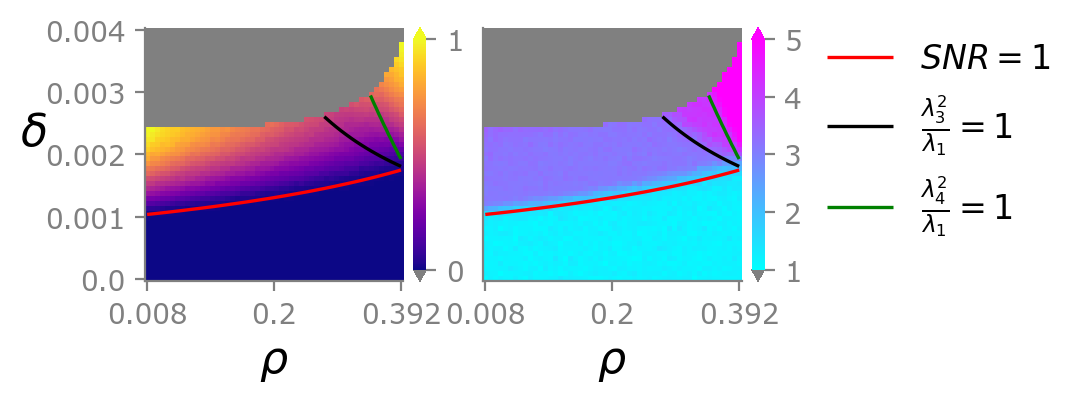

In [6]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 2))
# fig = plt.figure(figsize=(16, 16))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
for i, zi in enumerate(sub_ami):
    if zi != -1 and zi<0:
        sub_ami[i] = 0  # close the minor negative gap close to 0
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, ytickprecision=3)

plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=5, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)


lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BH_samed" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + "_highresolution.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

## 1,1 consistent pout BH

In [4]:
from EXPERIMENT_MINORITY import read_exp

In [44]:
# For big n
n = 6000
d = 5
Z_s = 1
Z_b = 1
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
fileID = 'amiExp25.4.2' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                          f'{"givenNumGroup" if givenNumGroup else ""}_' \
                          f'{"DC" if DC else ""}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
addition_id = "30more"
fileID = 'amiExp25.4.5' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{addition_id}'
add_paths = ["./result/detectabilityWithMeta/" + fileID + ".txt"]
exclude_rho = None
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Additional result adding...


max_rho=0.5, min_delta=0, max_delta=0.0015
Experiment samples 2239, with snr>1 samples 460
minz=0, maxz=0.8543056, cticks=[0. 1.], clabel=['0', '1']
minz=1, maxz=5, cticks=[0.   0.25], clabel=['1', '2']


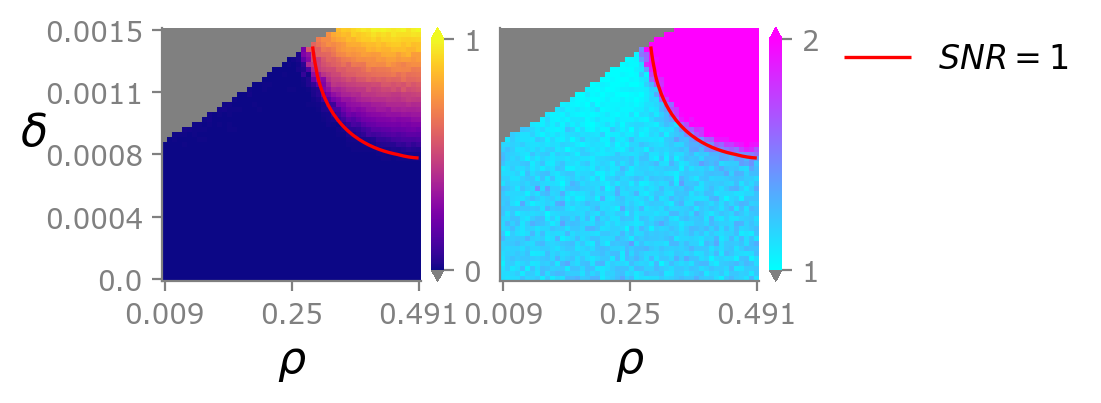

In [46]:
rhos, deltas, _, _ = explore_lambdas(n=6000, d=5, Z_s=1, Z_b=1, rho_len=54, delta_len=52, assortative=True, consist_d=False, num_lambda=2)
i = 0
for _rho in rhos:
    for _delta in deltas:
        pout = d / n - ((1-_rho)**2 / Z_b + _rho**2 / Z_s) * _delta
        pin = pout + _delta
        if pin < 0 or pin > 1 or pout < 0 or pout > 1:
            sub_ami[i] = -1
            sub_num_group[i] = -1
            lambdas[i] = [1, np.inf, np.inf, np.inf]
        i += 1
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 2))
# fig = plt.figure(figsize=(16, 16))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
for i, zi in enumerate(sub_ami):
    if zi != -1 and zi<0:
        sub_ami[i] = 0  # close the minor negative gap close to 0
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=4, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, ytickprecision=3)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)


lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BH_samed" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

## 1,2 consistent pout BH

In [12]:
# For big n
n = 6000
d = 5
Z_s = 1
Z_b = 2
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
fileID = 'amiExp25.4.3' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
addition_id = "30more"
fileID = 'amiExp25.4.5' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                              f'{"givenNumGroup" if givenNumGroup else ""}_{addition_id}' \
                              f'{"DC" if DC else ""}'
add_paths = ["./result/detectabilityWithMeta/" + fileID + ".txt"]
exclude_rho = None
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Additional result adding...


max_rho=0.3333333333333333, min_delta=0, max_delta=0.0023
Experiment samples 2486, with snr>1 samples 1439
minz=0, maxz=0.8912864000000005, cticks=[0. 1.], clabel=['0', '1']


D:\Work\PhD\_code\_nodeclassification\_FigureJiazeHelper.py:141: RuntimeWarning: invalid value encountered in scalar divide
  norm_z[i] = (z[i] - z_center) / (maxz - z_center) * 0.5 + 0.5


minz=1, maxz=5, cticks=[0.   0.25 0.5 ], clabel=['1', '2', '3']


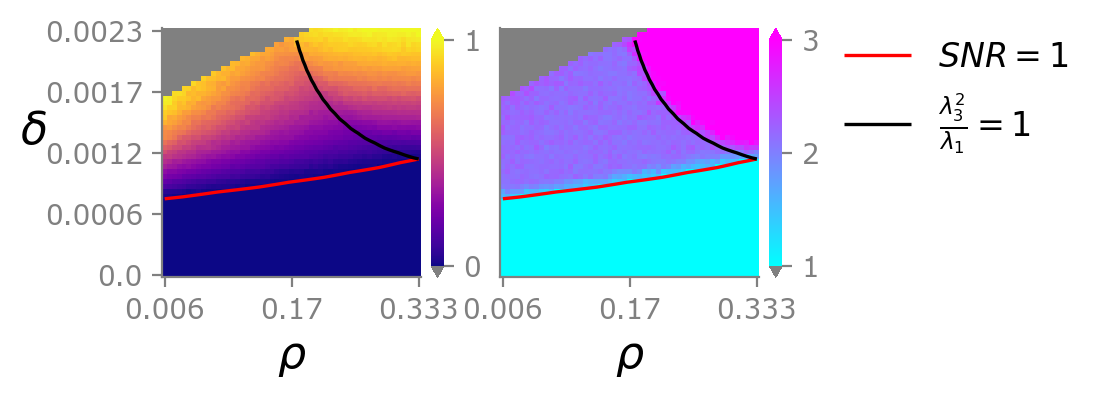

In [13]:
rhos, deltas, _, _ = explore_lambdas(n=6000, d=5, Z_s=1, Z_b=2, rho_len=54, delta_len=52, assortative=True, consist_d=False, num_lambda=3)
i = 0
for _rho in rhos:
    for _delta in deltas:
        pout = d / n - ((1-_rho)**2 / Z_b + _rho**2 / Z_s) * _delta
        pin = pout + _delta
        if pin < 0 or pin > 1 or pout < 0 or pout > 1:
            sub_ami[i] = -1
            sub_num_group[i] = -1
            lambdas[i] = [1, np.inf, np.inf, np.inf]
        else:
            l = MetaSBM.get_lambdas(n, _rho, Z_s, Z_b, pin, pout)
            snr = l[1]**2/l[0]
            if snr < 1:
                sub_ami[i] = 0
                sub_num_group[i] = 1
        i += 1
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 2))
# fig = plt.figure(figsize=(16, 16))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
for i, zi in enumerate(sub_ami):
    if zi != -1 and zi<0:
        sub_ami[i] = 0  # close the minor negative gap close to 0
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=4, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, ytickprecision=3)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)

lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BH_samepout" + f'_d{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

Metadata generation done!
number of groups = 2, Kpos=2, Kneg=0
True Sub Group Number is 3
BH Sub Group Number is 2
True index is [1 2], Community detected index is [1 0]
rho is 0.17, AMI is 0.3657766603257506, Confusion Matrix is
 [[ 410.  605.]
 [2181.  273.]
 [ 202. 2294.]]
Metadata generation done!
number of groups = 3, Kpos=3, Kneg=0
True Sub Group Number is 3
BH Sub Group Number is 3
True index is [0 1 2], Community detected index is [0 1 2]
rho is 0.32, AMI is 0.249221432766396, Confusion Matrix is
 [[1430.  273.  220.]
 [ 404. 1351.  260.]
 [ 385.  295. 1374.]]


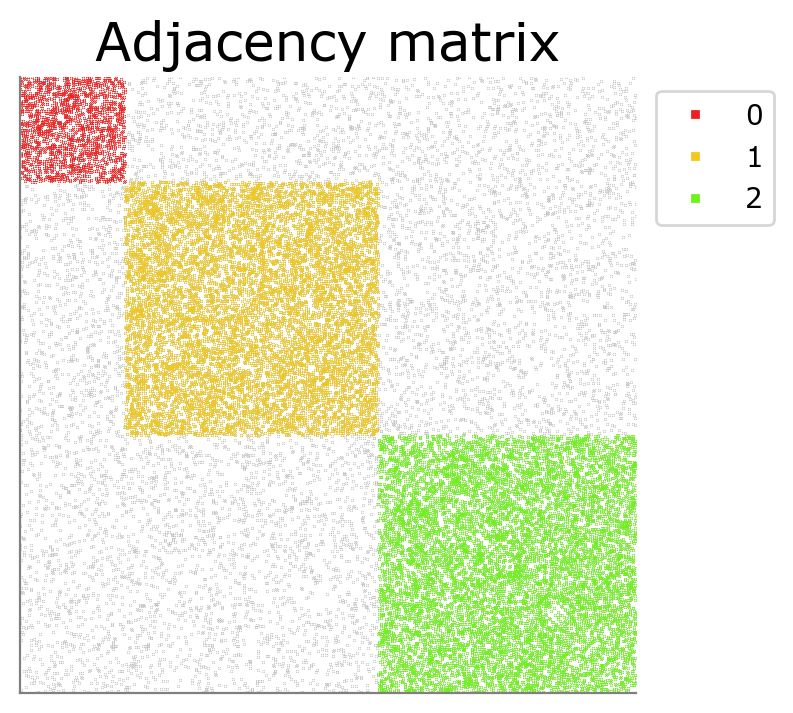

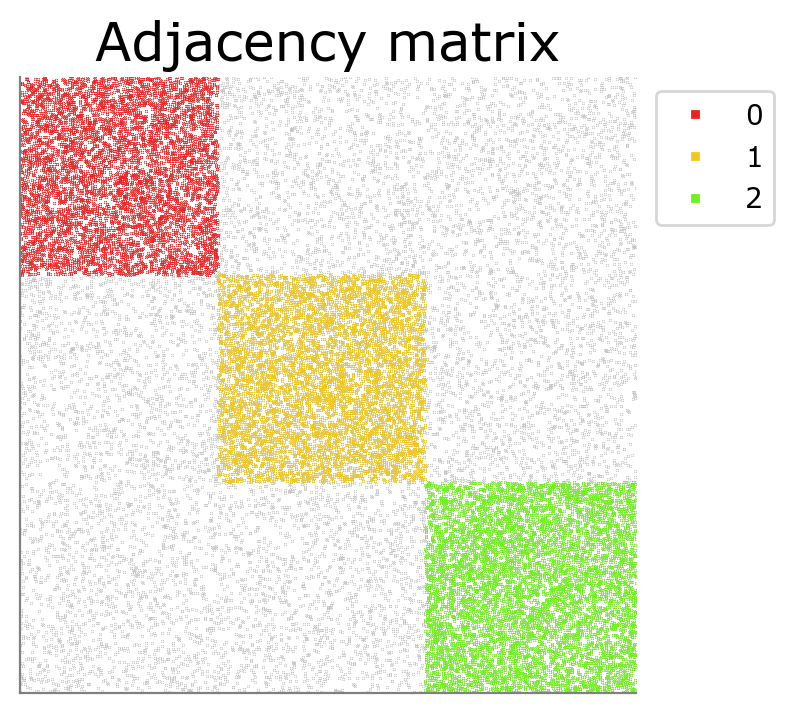

In [14]:
delta=0.0014
rho=0.17
cm1 = cm_for_network(delta=delta, rho=rho, n=n, d=d, Z_s=Z_s, Z_b=Z_b)

delta=0.0014
rho=0.32
cm2 = cm_for_network(delta=delta, rho=rho, n=n, d=d, Z_s=Z_s, Z_b=Z_b)

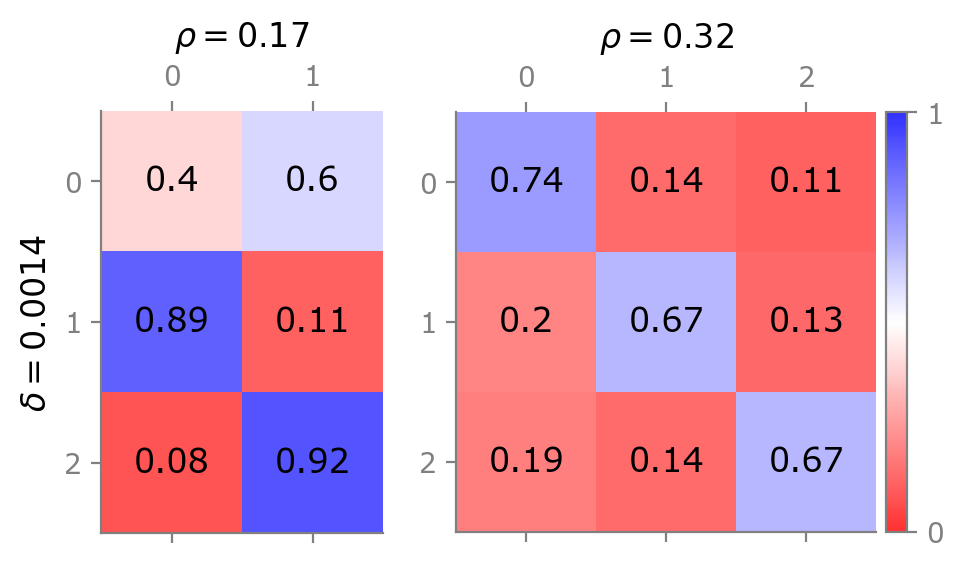

In [17]:
fig = plt.figure(figsize=(5.2, 3))
widths = [2, 3.2]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
delta=0.0014
rho=0.17
_ = plot_cm(confusionMatrix=cm1, rho=rho, delta=delta, fig=fig, ax=ax)
ax.set_title(rf"$\rho={rho}$", fontsize=12)
ax.set_ylabel(rf"$\delta={delta}$", rotation='vertical', fontsize=12)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
delta=0.0014
rho=0.32
im = plot_cm(confusionMatrix=cm2, rho=rho, delta=delta, fig=fig, ax=ax)
ax.set_title(rf"$\rho={rho}$", fontsize=12)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
# cticks = [0, 0.25, 0.5, 0.75, 1]
cticks = [0, 1]
clabels = ["0", "1"]
cbar = fig.colorbar(im, cax=cax, ticks=cticks)
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_yticklabels(clabels)

plt.subplots_adjust(hspace=0.4)
save_path = "./_Figure/Minority/" + "FigureMinorityCM_samepout_" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600)

## 2,1 consistent pout BH

In [69]:
# For big n
n = 6000
d = 5
Z_s = 2
Z_b = 1
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
skip_snrlower1 = True
fileID = 'amiExp25.4.4' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                          f'{"givenNumGroup" if givenNumGroup else ""}_' \
                          f'{"DC" if DC else ""}_{"skipSNR_1" if skip_snrlower1 else ""}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
addition_id = "30more"
fileID = 'amiExp25.4.5' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"skipSNR_1" if skip_snrlower1 else ""}_{addition_id}'
add_paths = ["./result/detectabilityWithMeta/" + fileID + ".txt"]
exclude_rho = None
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Additional result adding...


minz=0, maxz=0.8953297999999998, cticks=[0. 1.], clabel=['0', '1']
minz=1, maxz=5, cticks=[0.   0.25 0.5 ], clabel=['1', '2', '3']


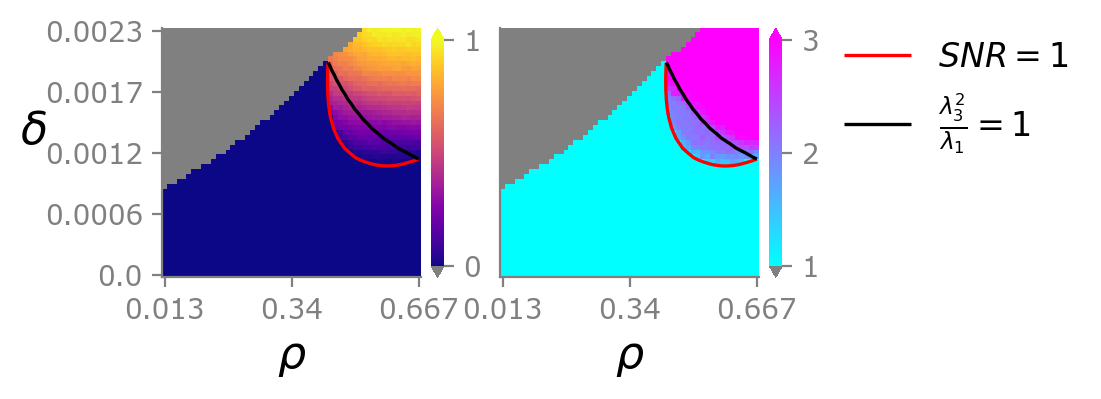

In [73]:
# rhos, deltas, _, _ = explore_lambdas(n=6000, d=5, Z_s=1, Z_b=2, rho_len=54, delta_len=52, assortative=True, consist_d=False, num_lambda=3)
# i = 0
# for _rho in rhos:
#     for _delta in deltas:
#         pout = d / n - ((1-_rho)**2 / Z_b + _rho**2 / Z_s) * _delta
#         pin = pout + _delta
#         if pin < 0 or pin > 1 or pout < 0 or pout > 1:
#             sub_ami[i] = -1
#             sub_num_group[i] = -1
#             lambdas[i] = [1, np.inf, np.inf, np.inf]
#         i += 1
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 2))
# fig = plt.figure(figsize=(16, 16))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
for i, zi in enumerate(sub_ami):
    if zi != -1 and zi<0:
        sub_ami[i] = 0  # close the minor negative gap close to 0
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=4, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, ytickprecision=3)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)


row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)

lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BH_samepout" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

Metadata generation done!
number of groups = 2, Kpos=2, Kneg=0
True Sub Group Number is 3
BH Sub Group Number is 2
True index is [1 2], Community detected index is [0 1]
rho is 0.5, AMI is 0.24494105433455732, Confusion Matrix is
 [[1115.  318.]
 [1302.  202.]
 [ 609. 2420.]]
Metadata generation done!
number of groups = 3, Kpos=3, Kneg=0
True Sub Group Number is 3
BH Sub Group Number is 3
True index is [0 1 2], Community detected index is [1 0 2]
rho is 0.65, AMI is 0.30007203761589424, Confusion Matrix is
 [[1334.  314.  289.]
 [ 277. 1408.  287.]
 [ 264.  194. 1638.]]


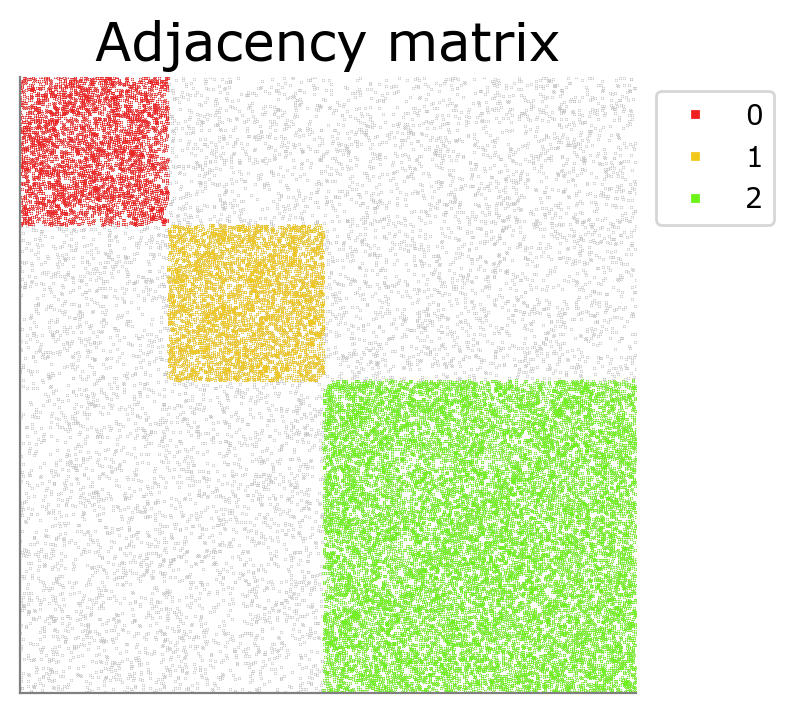

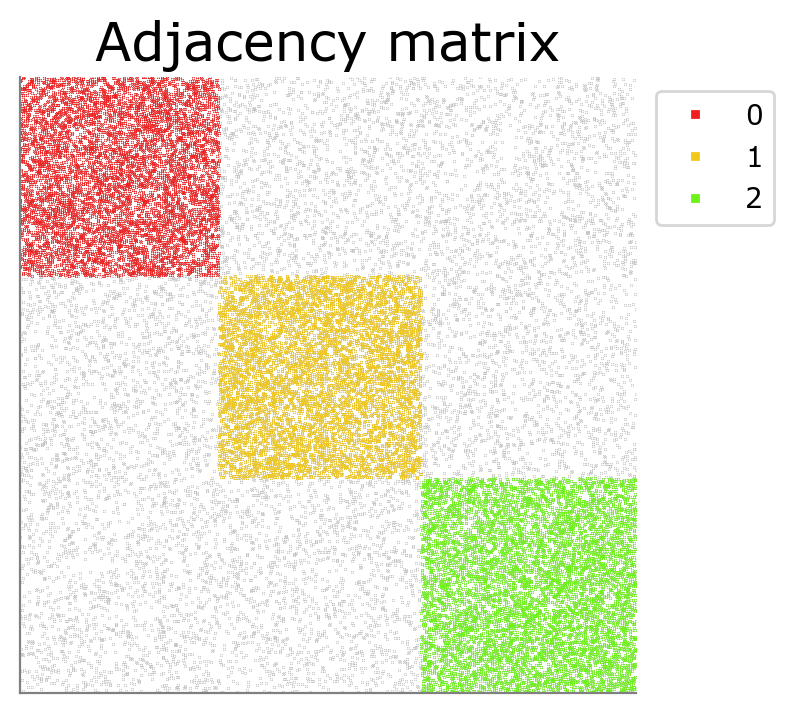

In [80]:
delta=0.0014
rho=0.5
cm1 = cm_for_network(delta=delta, rho=rho, n=n, d=d, Z_s=Z_s, Z_b=Z_b)

delta=0.0014
rho=0.65
cm2 = cm_for_network(delta=delta, rho=rho, n=n, d=d, Z_s=Z_s, Z_b=Z_b)

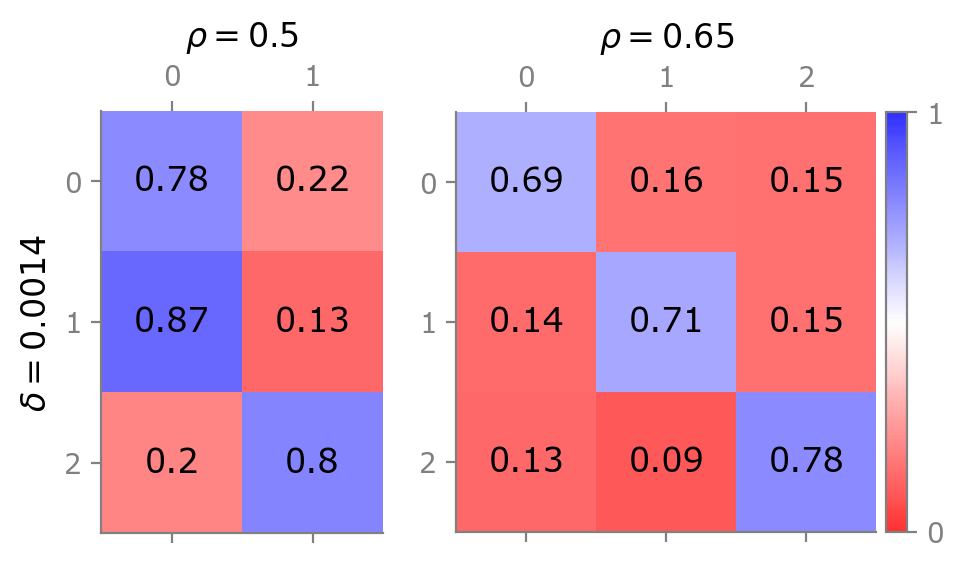

In [82]:
fig = plt.figure(figsize=(5.2, 3))
widths = [2, 3.2]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
delta=0.0014
rho=0.5
_ = plot_cm(confusionMatrix=cm1, rho=rho, delta=delta, fig=fig, ax=ax)
ax.set_title(rf"$\rho={rho}$", fontsize=12)
ax.set_ylabel(rf"$\delta={delta}$", rotation='vertical', fontsize=12)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
delta=0.0014
rho=0.65
_ = plot_cm(confusionMatrix=cm2, rho=rho, delta=delta, fig=fig, ax=ax)
ax.set_title(rf"$\rho={rho}$", fontsize=12)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
# cticks = [0, 0.25, 0.5, 0.75, 1]
cticks = [0, 1]
clabels = ["0", "1"]
cbar = fig.colorbar(im, cax=cax, ticks=cticks)
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_yticklabels(clabels)

plt.subplots_adjust(hspace=0.4)
save_path = "./_Figure/Minority/" + "FigureMinorityCM_samepout_" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600)

## 2,3 consistent pout BH

In [66]:
# For big n
n = 6000
d = 5
Z_s = 2
Z_b = 3
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
skip_snrlower1 = True
fileID = 'amiExp25.4.4' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                          f'{"givenNumGroup" if givenNumGroup else ""}_' \
                          f'{"DC" if DC else ""}_{"skipSNR_1" if skip_snrlower1 else ""}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
addition_id = "30more"
fileID = 'amiExp25.4.5' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"skipSNR_1" if skip_snrlower1 else ""}_{addition_id}'
add_paths = ["./result/detectabilityWithMeta/" + fileID + ".txt"]
exclude_rho = None
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Additional result adding...


minz=0, maxz=0.9574300000000002, cticks=[0. 1.], clabel=['0', '1']
minz=1, maxz=5, cticks=[0.   0.25 0.5  0.75 1.  ], clabel=['1', '2', '3', '4', '5']


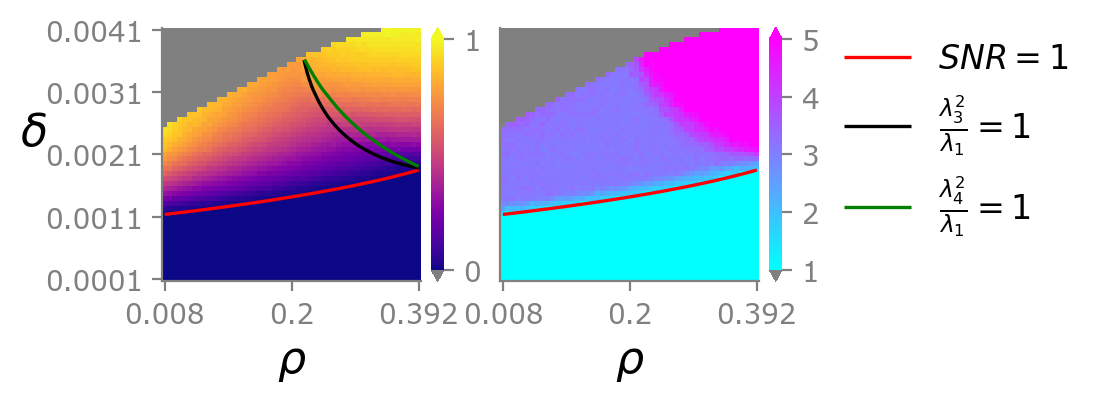

In [68]:
# rhos, deltas, _, _ = explore_lambdas(n=6000, d=5, Z_s=1, Z_b=2, rho_len=54, delta_len=52, assortative=True, consist_d=False, num_lambda=3)
# i = 0
# for _rho in rhos:
#     for _delta in deltas:
#         pout = d / n - ((1-_rho)**2 / Z_b + _rho**2 / Z_s) * _delta
#         pin = pout + _delta
#         if pin < 0 or pin > 1 or pout < 0 or pout > 1:
#             sub_ami[i] = -1
#             sub_num_group[i] = -1
#             lambdas[i] = [1, np.inf, np.inf, np.inf]
#         i += 1
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 2))
# fig = plt.figure(figsize=(16, 16))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
for i, zi in enumerate(sub_ami):
    if zi != -1 and zi<0:
        sub_ami[i] = 0  # close the minor negative gap close to 0
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=4, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, ytickprecision=3)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
# plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
# plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
# save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BH_samed" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
# # plt.tight_layout()
# plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

## 2,2 consistent pout BH learnqby BH

In [6]:
# For big n
n = 6000
d = 5
Z_s = 2
Z_b = 2
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
skip_snrlower1 = True
fileID = 'amiExp25.4.5' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                          f'{"givenNumGroup" if givenNumGroup else ""}_' \
                          f'{"DC" if DC else ""}_{"skipSNR_1" if skip_snrlower1 else ""}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
addition_id = "30more"
fileID = 'amiExp25.4.5' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"skipSNR_1" if skip_snrlower1 else ""}_{addition_id}'
add_paths = ["./result/detectabilityWithMeta/" + fileID + ".txt"]
exclude_rho = None
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Additional result adding...


minz=0, maxz=0.9484249999999999, cticks=[0. 1.], clabel=['0', '1']
minz=1, maxz=5, cticks=[0.   0.25 0.5  0.75], clabel=['1', '2', '3', '4']


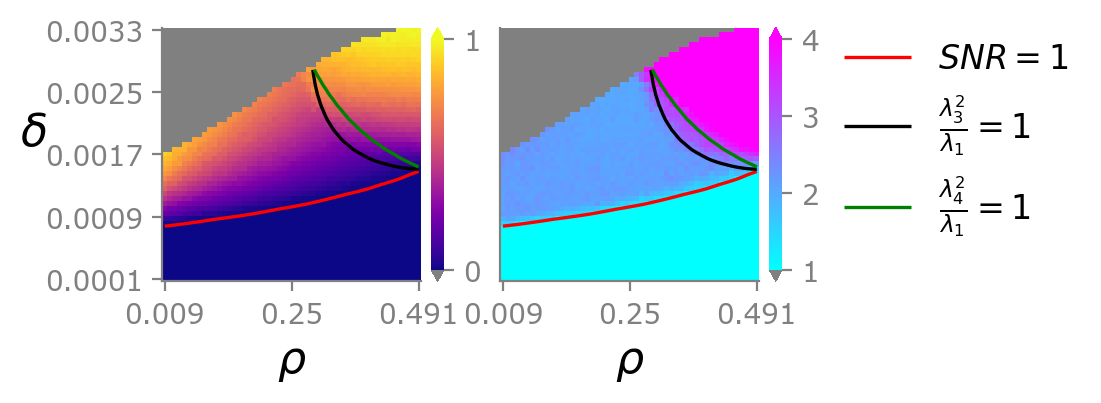

In [53]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 2))
# fig = plt.figure(figsize=(16, 16))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
for i, zi in enumerate(sub_ami):
    if zi != -1 and zi<0:
        sub_ami[i] = 0  # close the minor negative gap close to 0
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=4, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, ytickprecision=3)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BH_samed" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

Metadata generation done!
number of groups = 2, Kpos=2, Kneg=0
True Sub Group Number is 4
BH Sub Group Number is 2
True index is [2 3], Community detected index is [1 0]
rho is 0.25, AMI is 0.4373626393479207, Confusion Matrix is
 [[ 161.  584.]
 [ 158.  575.]
 [2100.  142.]
 [  47. 2217.]]
Metadata generation done!
number of groups = 3, Kpos=3, Kneg=0
True Sub Group Number is 4
BH Sub Group Number is 3
True index is [0 2 3], Community detected index is [1 0 2]
rho is 0.39, AMI is 0.3235495527908432, Confusion Matrix is
 [[ 886.  117.  141.]
 [ 860.  103.  165.]
 [ 393. 1361.   64.]
 [ 368.   94. 1373.]]
Metadata generation done!
number of groups = 4, Kpos=4, Kneg=0
True Sub Group Number is 4
BH Sub Group Number is 4
True index is [0 1 2 3], Community detected index is [1 0 2 3]
rho is 0.44, AMI is 0.32264826811839326, Confusion Matrix is
 [[ 976.  179.  120.   85.]
 [ 301.  834.   85.   89.]
 [ 348.  118. 1118.   75.]
 [ 243.  147.  110. 1157.]]


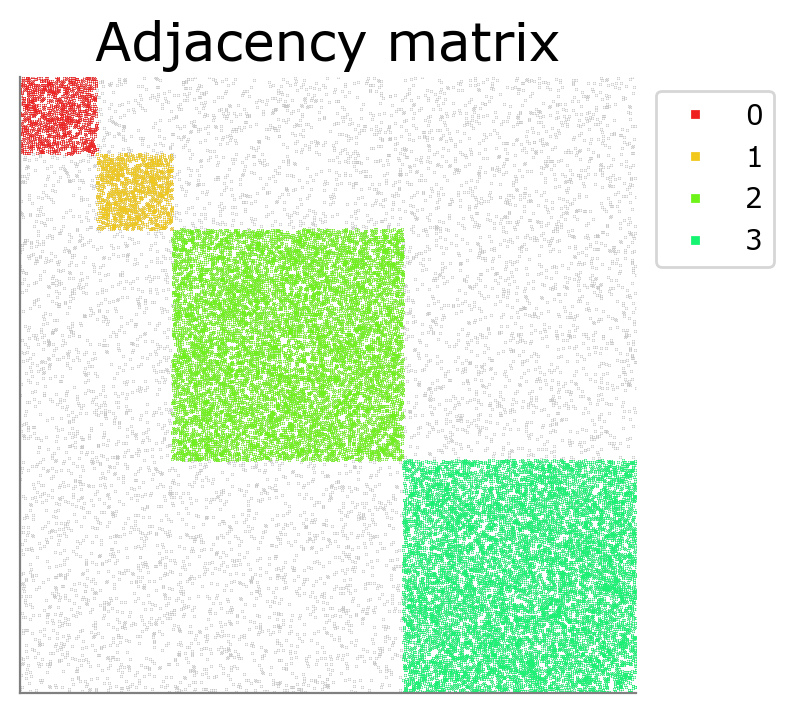

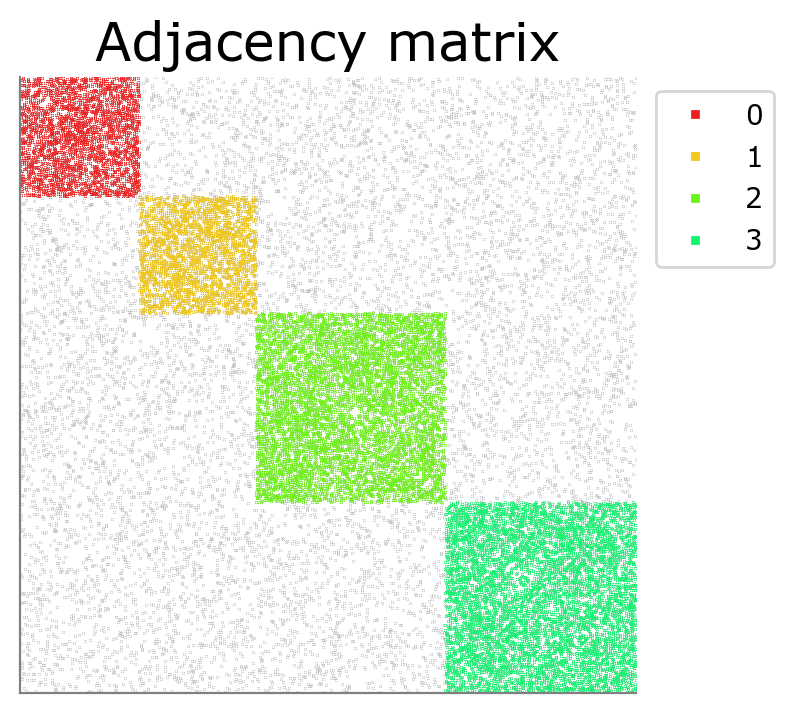

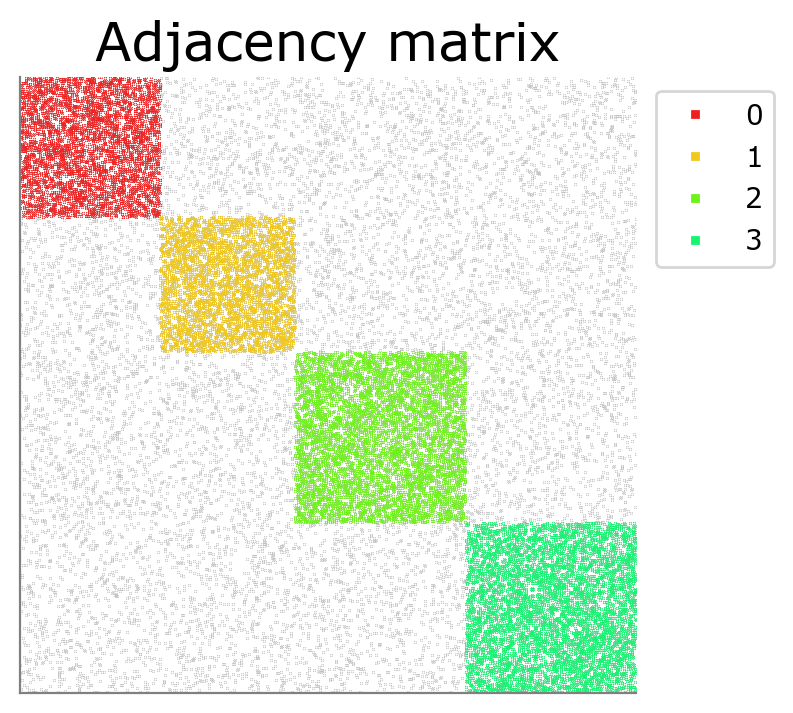

In [63]:
delta=0.0019
rho=0.25
cm1 = cm_for_network(delta=delta, rho=rho, n=n, d=d, Z_s=Z_s, Z_b=Z_b)

delta=0.0019
rho=0.39
cm2 = cm_for_network(delta=delta, rho=rho, n=n, d=d, Z_s=Z_s, Z_b=Z_b)

delta=0.0019
rho=0.44
cm3 = cm_for_network(delta=delta, rho=rho, n=n, d=d, Z_s=Z_s, Z_b=Z_b)

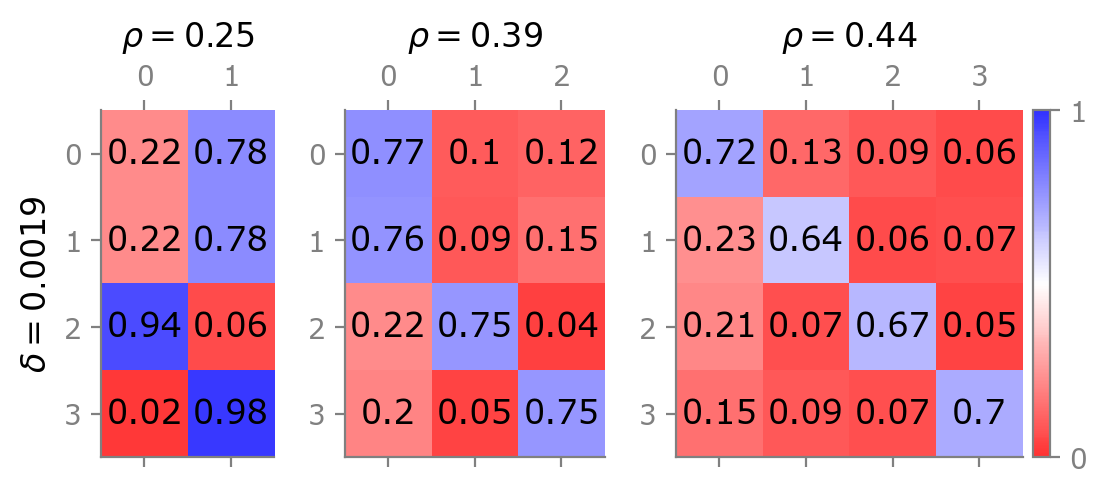

In [65]:
fig = plt.figure(figsize=(6.2, 5.4))
widths = [2, 3, 4.2]
heights = [4, 4]
spec5 = fig.add_gridspec(ncols=3, nrows=2, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
delta=0.0019
rho=0.25
_ = plot_cm(confusionMatrix=cm1, rho=rho, delta=delta, fig=fig, ax=ax)
ax.set_title(rf"$\rho={rho}$", fontsize=12)
ax.set_ylabel(rf"$\delta={delta}$", rotation='vertical', fontsize=12)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
delta=0.0019
rho=0.39
_ = plot_cm(confusionMatrix=cm2, rho=rho, delta=delta, fig=fig, ax=ax)
ax.set_title(rf"$\rho={rho}$", fontsize=12)

row = 0
col = 2
ax = fig.add_subplot(spec5[row, col])
delta=0.0019
rho=0.44
im = plot_cm(confusionMatrix=cm3, rho=rho, delta=delta, fig=fig, ax=ax)
ax.set_title(rf"$\rho={rho}$", fontsize=12)

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
# cticks = [0, 0.25, 0.5, 0.75, 1]
cticks = [0, 1]
clabels = ["0", "1"]
cbar = fig.colorbar(im, cax=cax, ticks=cticks)
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_yticklabels(clabels)

plt.subplots_adjust(hspace=0.4)
save_path = "./_Figure/Minority/" + "FigureMinorityCM_samepout_" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600)

D:\BackProgram\Anaconda\envs\network\Lib\site-packages\matplotlib_inline\config.py:68: DeprecationWarning: InlineBackend._figure_format_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_format_changed(self, name, old, new):
D:\Work\PhD\_code\_nodeclassification\_FigureJiazeHelper.py:141: RuntimeWarning: invalid value encountered in scalar divide
  norm_z[i] = (z[i] - z_center) / (maxz - z_center) * 0.5 + 0.5


minz=0, maxz=0.9484249999999999, cticks=[0. 1.], clabel=['0', '1']
minz=1, maxz=5, cticks=[0.   0.25 0.5  0.75], clabel=['1', '2', '3', '4']


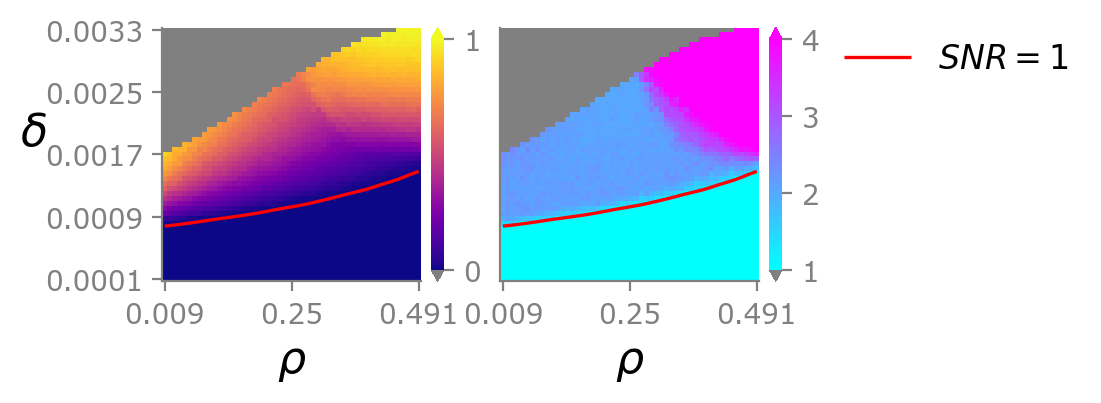

In [7]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 2))
# fig = plt.figure(figsize=(16, 16))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
for i, zi in enumerate(sub_ami):
    if zi != -1 and zi<0:
        sub_ami[i] = 0  # close the minor negative gap close to 0
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=4, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, ytickprecision=3)
# plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
# plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
# plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
# plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BH_samed" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + "_nominoritycurve.pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

## 2,2 consistent pout BP learnqby BH

In [8]:
# For big n
n = 6000
d = 5
Z_s = 2
Z_b = 2
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = True
learnqby = None
givenTrueEpsilon = False
writeCM = False
skip_snrlower1 = True
additionId = "BP_learnq_NegEig"
fileID = 'amiExp25.4.8' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                           f'{"givenNumGroup" if givenNumGroup else ""}_' \
                           f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                           f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                           f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
# addition_id = "30more"
# fileID = 'amiExp25.4.5' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
#                               f'{"givenNumGroup" if givenNumGroup else ""}_' \
#                               f'{"DC" if DC else ""}_{"skipSNR_1" if skip_snrlower1 else ""}_{addition_id}'
# add_paths = ["./result/detectabilityWithMeta/" + fileID + ".txt"]
add_paths = []
exclude_rho = None
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Additional result adding...


max_rho=0.5, min_delta=0, max_delta=0.0033
Experiment samples 2081, with snr>1 samples 1274
minz=0, maxz=0.974559, cticks=[0. 1.], clabel=['0', '1']


D:\Work\PhD\_code\_nodeclassification\_FigureJiazeHelper.py:141: RuntimeWarning: invalid value encountered in scalar divide
  norm_z[i] = (z[i] - z_center) / (maxz - z_center) * 0.5 + 0.5


minz=1, maxz=5, cticks=[0.   0.25 0.5  0.75], clabel=['1', '2', '3', '4']


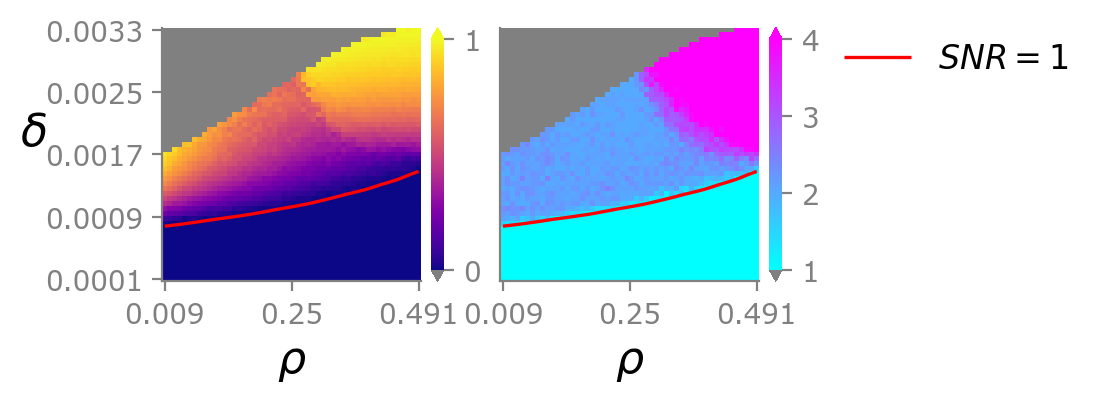

In [11]:
rhos, deltas, _, _ = explore_lambdas(n=6000, d=5, Z_s=2, Z_b=2, rho_len=54, delta_len=52, assortative=True, consist_d=False, num_lambda=4)
i = 0
for _rho in rhos:
    for _delta in deltas:
        pout = d / n - ((1-_rho)**2 / Z_b + _rho**2 / Z_s) * _delta
        pin = pout + _delta
        if pin < 0 or pin > 1 or pout < 0 or pout > 1:
            sub_ami[i] = -1
            sub_num_group[i] = -1
            lambdas[i] = [1, np.inf, np.inf, np.inf]
        i += 1
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 2))
# fig = plt.figure(figsize=(16, 16))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
for i, zi in enumerate(sub_ami):
    if zi != -1 and zi<0:
        sub_ami[i] = 0  # close the minor negative gap close to 0
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=4, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, ytickprecision=3)
# plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
# plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
# plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
# plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BPlearnqBH_samepout" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

## 2,2 consistent pout BH learnqby MDL

In [12]:
# For big n
n = 6000
d = 5
Z_s = 2
Z_b = 2
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
learnqby = "MDL"
givenTrueEpsilon = False
writeCM = False
skip_snrlower1 = True
additionId = "BH_learnq_MDL"
fileID = 'amiExp25.4.8' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                           f'{"givenNumGroup" if givenNumGroup else ""}_' \
                           f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                           f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                           f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
# addition_id = "30more"
# fileID = 'amiExp25.4.5' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
#                               f'{"givenNumGroup" if givenNumGroup else ""}_' \
#                               f'{"DC" if DC else ""}_{"skipSNR_1" if skip_snrlower1 else ""}_{addition_id}'
# add_paths = ["./result/detectabilityWithMeta/" + fileID + ".txt"]
add_paths = []
exclude_rho = None
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Additional result adding...


max_rho=0.5, min_delta=0, max_delta=0.0033
Experiment samples 2081, with snr>1 samples 1274
minz=0, maxz=0.969819, cticks=[0. 1.], clabel=['0', '1']


D:\Work\PhD\_code\_nodeclassification\_FigureJiazeHelper.py:141: RuntimeWarning: invalid value encountered in scalar divide
  norm_z[i] = (z[i] - z_center) / (maxz - z_center) * 0.5 + 0.5


minz=1, maxz=5, cticks=[0.   0.25 0.5  0.75], clabel=['1', '2', '3', '4']


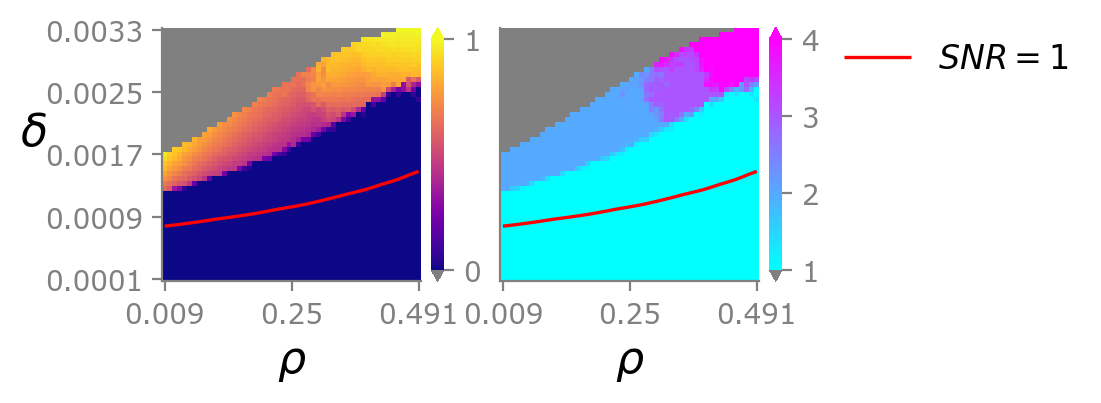

In [13]:
rhos, deltas, _, _ = explore_lambdas(n=6000, d=5, Z_s=2, Z_b=2, rho_len=54, delta_len=52, assortative=True, consist_d=False, num_lambda=4)
i = 0
for _rho in rhos:
    for _delta in deltas:
        pout = d / n - ((1-_rho)**2 / Z_b + _rho**2 / Z_s) * _delta
        pin = pout + _delta
        if pin < 0 or pin > 1 or pout < 0 or pout > 1:
            sub_ami[i] = -1
            sub_num_group[i] = -1
            lambdas[i] = [1, np.inf, np.inf, np.inf]
        i += 1
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 2))
# fig = plt.figure(figsize=(16, 16))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
for i, zi in enumerate(sub_ami):
    if zi != -1 and zi<0:
        sub_ami[i] = 0  # close the minor negative gap close to 0
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=4, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, ytickprecision=3)
# plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
# plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
# plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
# plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BHlearnqMDL_samepout" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

## 2,2 consistent pout BP learnqby MDL

In [14]:
# For big n
n = 6000
d = 5
Z_s = 2
Z_b = 2
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = True
learnqby = "MDL"
givenTrueEpsilon = False
writeCM = False
skip_snrlower1 = True
additionId = "BP_learnq_MDL"
fileID = 'amiExp25.4.8' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                           f'{"givenNumGroup" if givenNumGroup else ""}_' \
                           f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                           f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                           f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
# addition_id = "30more"
# fileID = 'amiExp25.4.5' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
#                               f'{"givenNumGroup" if givenNumGroup else ""}_' \
#                               f'{"DC" if DC else ""}_{"skipSNR_1" if skip_snrlower1 else ""}_{addition_id}'
# add_paths = ["./result/detectabilityWithMeta/" + fileID + ".txt"]
add_paths = []
exclude_rho = None
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Additional result adding...


max_rho=0.5, min_delta=0, max_delta=0.0033
Experiment samples 2081, with snr>1 samples 1274
minz=0, maxz=0.9751529999999999, cticks=[0. 1.], clabel=['0', '1']


D:\Work\PhD\_code\_nodeclassification\_FigureJiazeHelper.py:141: RuntimeWarning: invalid value encountered in scalar divide
  norm_z[i] = (z[i] - z_center) / (maxz - z_center) * 0.5 + 0.5


minz=1, maxz=5, cticks=[0.   0.25 0.5  0.75], clabel=['1', '2', '3', '4']


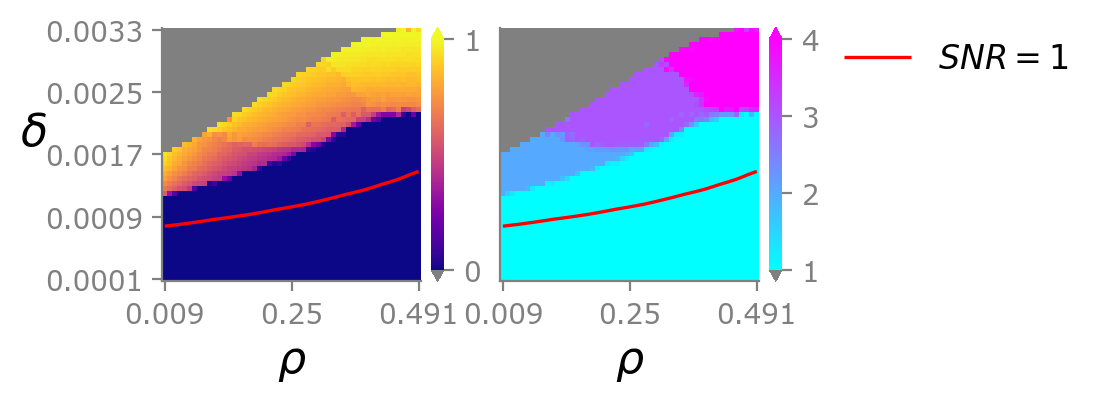

In [15]:
rhos, deltas, _, _ = explore_lambdas(n=6000, d=5, Z_s=2, Z_b=2, rho_len=54, delta_len=52, assortative=True, consist_d=False, num_lambda=4)
i = 0
for _rho in rhos:
    for _delta in deltas:
        pout = d / n - ((1-_rho)**2 / Z_b + _rho**2 / Z_s) * _delta
        pin = pout + _delta
        if pin < 0 or pin > 1 or pout < 0 or pout > 1:
            sub_ami[i] = -1
            sub_num_group[i] = -1
            lambdas[i] = [1, np.inf, np.inf, np.inf]
        i += 1
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 2))
# fig = plt.figure(figsize=(16, 16))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
cmap.set_extremes(under='gray')
for i, zi in enumerate(sub_ami):
    if zi != -1 and zi<0:
        sub_ami[i] = 0  # close the minor negative gap close to 0
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              min_z=0, cmap=cmap, 
                              ax=ax, fig=fig, vmin=0, ytickprecision=4, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', 
                              cmap=cmap, 
                              ax=ax, fig=fig, return_gridz=True, ytickprecision=3)
# plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
# plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 3
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_ext_color=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
# plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
# plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
# contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)

lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_BPlearnqMDL_samepout" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

## 2,2 consistent pout different method (only show # community)

In [3]:
# For big n
n = 6000
d = 5
Z_s = 2
Z_b = 2
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
skip_snrlower1 = True
fileID = 'amiExp25.4.5' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                          f'{"givenNumGroup" if givenNumGroup else ""}_' \
                          f'{"DC" if DC else ""}_{"skipSNR_1" if skip_snrlower1 else ""}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
addition_id = "30more"
fileID = 'amiExp25.4.5' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_{"skipSNR_1" if skip_snrlower1 else ""}_{addition_id}'
add_paths = ["./result/detectabilityWithMeta/" + fileID + ".txt"]
exclude_rho = None
plot_rhos, plot_zs, sub_ami, BH_BH_sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Withlambda = True
givenNumGroup = False
DC = False
BP = True
learnqby = None
givenTrueEpsilon = False
writeCM = False
skip_snrlower1 = True
additionId = "BP_learnq_NegEig"
fileID = 'amiExp25.4.8' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                           f'{"givenNumGroup" if givenNumGroup else ""}_' \
                           f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                           f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                           f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
add_paths = []
exclude_rho = None
plot_rhos, plot_zs, sub_ami, BP_BH_sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Withlambda = True
givenNumGroup = False
DC = False
BP = False
learnqby = "MDL"
givenTrueEpsilon = False
writeCM = False
skip_snrlower1 = True
additionId = "BH_learnq_MDL"
fileID = 'amiExp25.4.8' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                           f'{"givenNumGroup" if givenNumGroup else ""}_' \
                           f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                           f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                           f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
add_paths = []
exclude_rho = None
plot_rhos, plot_zs, sub_ami, BH_MDL_sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Withlambda = True
givenNumGroup = False
DC = False
BP = True
learnqby = "MDL"
givenTrueEpsilon = False
writeCM = False
skip_snrlower1 = True
additionId = "BP_learnq_MDL"
fileID = 'amiExp25.4.8' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                           f'{"givenNumGroup" if givenNumGroup else ""}_' \
                           f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                           f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                           f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
add_paths = []
exclude_rho = None
plot_rhos, plot_zs, sub_ami, BP_MDL_sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Withlambda = True
givenNumGroup = False
DC = False
BP = True
learnqby = "FE"
givenTrueEpsilon = False
writeCM = False
skip_snrlower1 = True
additionId = "BP_learnq_FE"
fileID = 'amiExp25.4.8' + f'_n={n}_qs={Z_s}_qb={Z_b}_d={round(d)}_{"lambda" if Withlambda else ""}_' \
                           f'{"givenNumGroup" if givenNumGroup else ""}_' \
                           f'{"DC" if DC else ""}_{"BP" if BP else ""}_' \
                           f'{"givenTrueEpsilon" if givenTrueEpsilon else ""}_{"writeCM" if writeCM else ""}_' \
                           f'{additionId}'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
add_paths = []
exclude_rho = None
plot_rhos, plot_zs, sub_ami, BP_FE_sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rho, add_paths=add_paths)

Additional result adding...
Additional result adding...
Additional result adding...
Additional result adding...
Additional result adding...


max_rho=0.5, min_delta=0, max_delta=0.0033
Experiment samples 2081, with snr>1 samples 1274
minz=1, maxz=5, cticks=[0.         0.26666667 0.53333333 0.8       ], clabel=['1', '2', '3', '4']
minz=1, maxz=5, cticks=[0.         0.26666667 0.53333333 0.8       ], clabel=['1', '2', '3', '4']


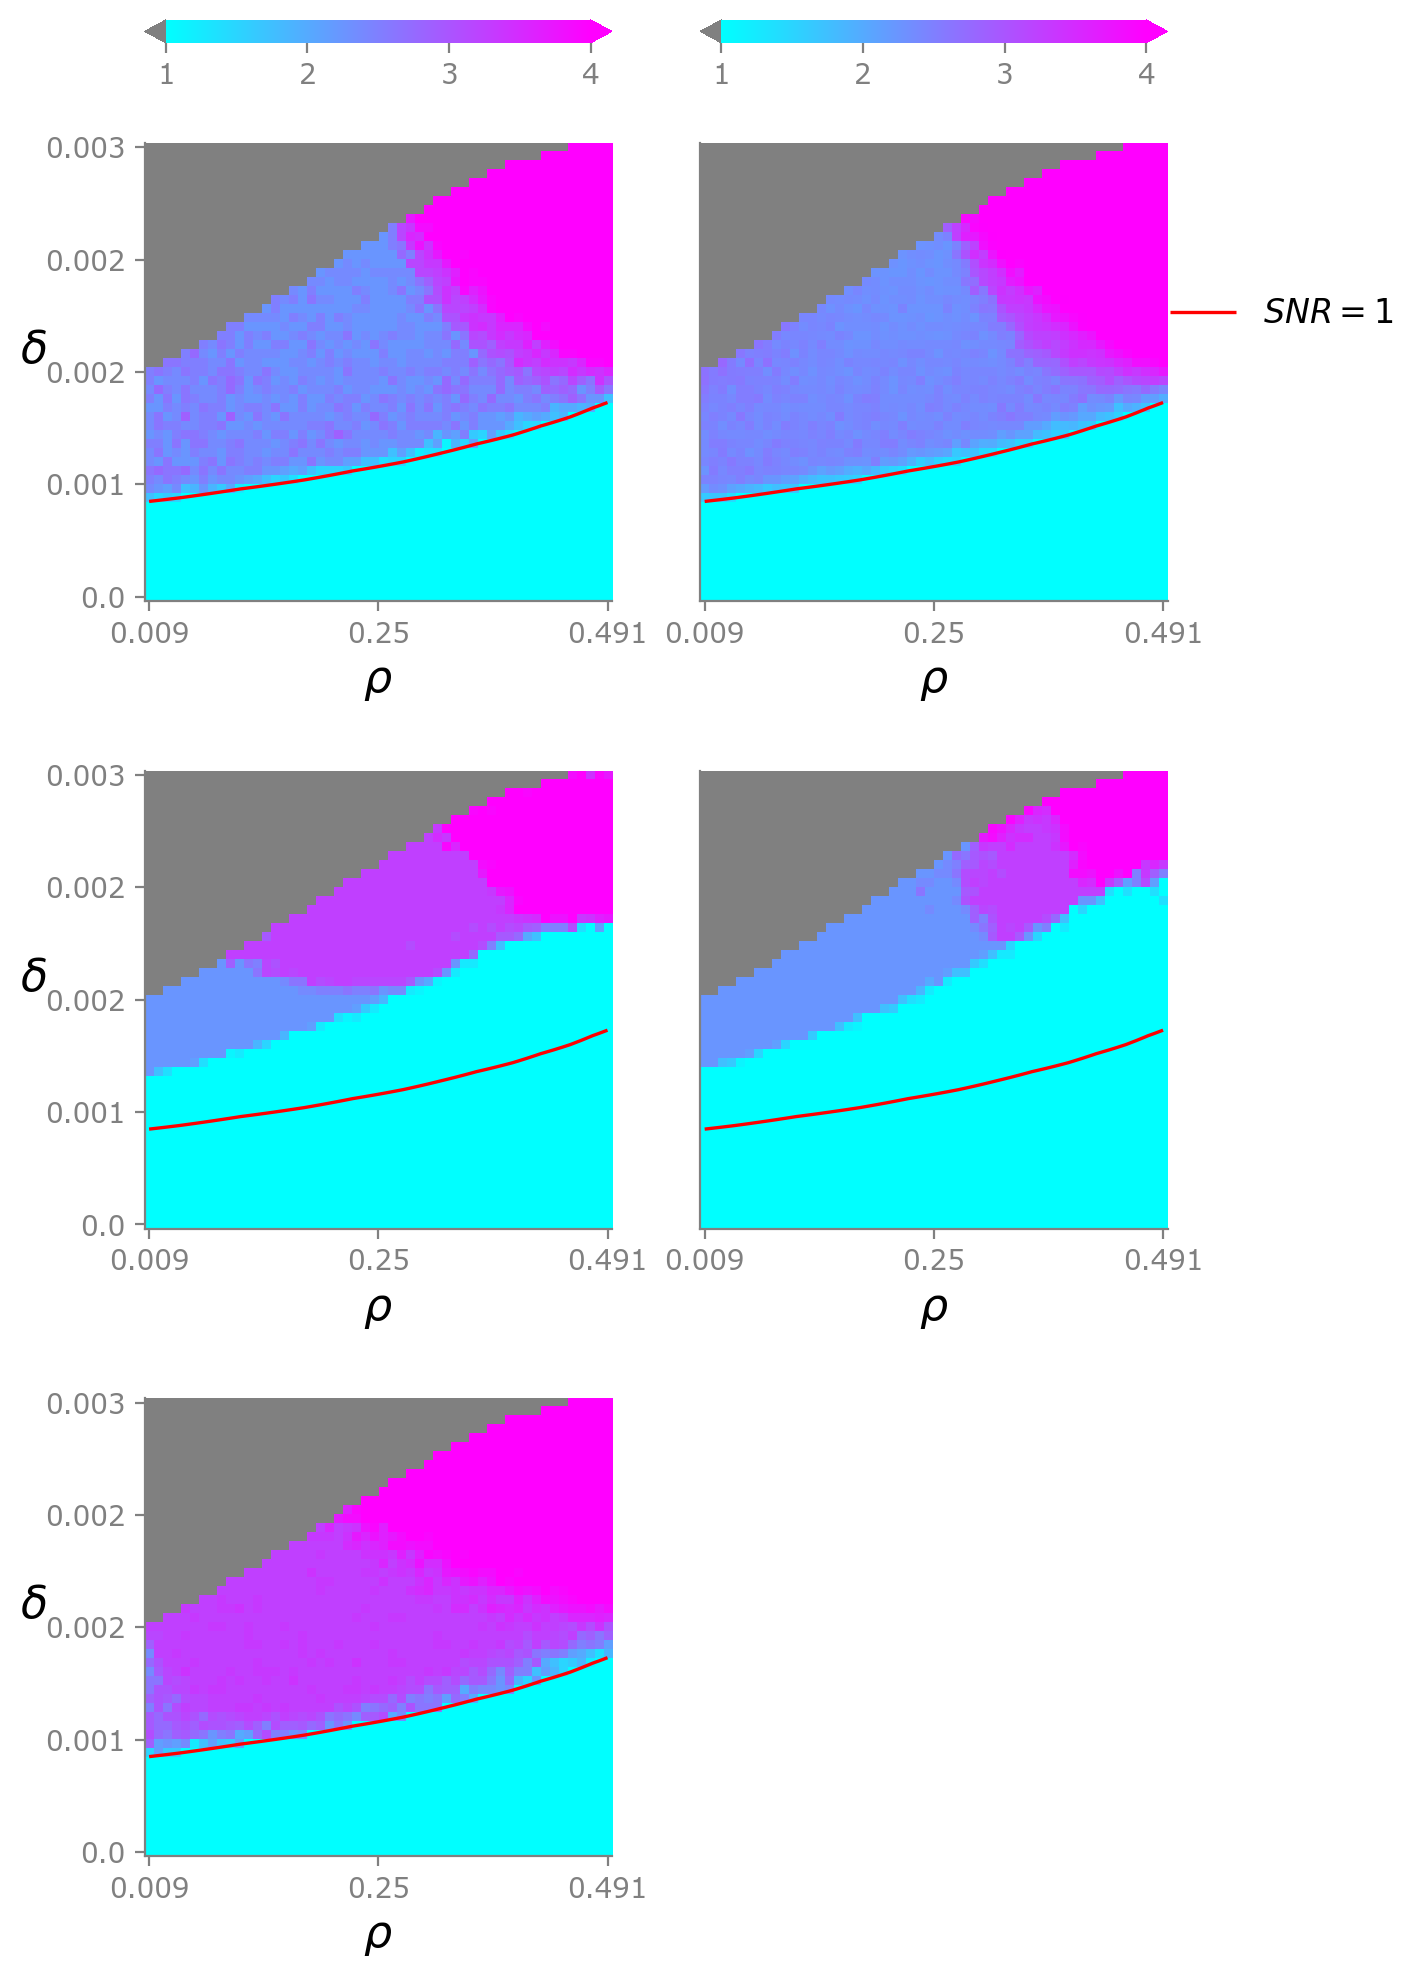

In [13]:
rhos, deltas, _, _ = explore_lambdas(n=6000, d=5, Z_s=2, Z_b=2, rho_len=54, delta_len=52, assortative=True, consist_d=False, num_lambda=4)
i = 0
for _rho in rhos:
    for _delta in deltas:
        pout = d / n - ((1-_rho)**2 / Z_b + _rho**2 / Z_s) * _delta
        pin = pout + _delta
        if pin < 0 or pin > 1 or pout < 0 or pout > 1:
            sub_ami[i] = -1
            BP_BH_sub_num_group[i] = -1
            BH_BH_sub_num_group[i] = -1
            lambdas[i] = [1, np.inf, np.inf, np.inf]
        i += 1
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(6, 10), layout='constrained')
# fig = plt.figure(figsize=(16, 16))
widths = [8, 8]
heights = [6, 5, 5]
spec5 = fig.add_gridspec(ncols=2, nrows=3, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])

# fig, axs = plt.subplots(3, 2, sharex=True, layout='constrained', figsize=(4, 6))
# ax = axs[0][0]
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 2.5
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, BP_BH_sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=True, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_colorbar=True, show_ext_color=True, top_cbar=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels = []
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
# ax = axs[0][1]
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 2.5
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, BH_BH_sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_colorbar=True, show_ext_color=True, top_cbar=True)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

row = 1
col = 0
ax = fig.add_subplot(spec5[row, col])
# ax = axs[1][0]
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 2.5
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, BP_MDL_sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=True, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_colorbar=False, show_ext_color=True, top_cbar=False)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

row = 1
col = 1
ax = fig.add_subplot(spec5[row, col])
# ax = axs[1][1]
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 2.5
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, BH_MDL_sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=False, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_colorbar=False, show_ext_color=True, top_cbar=False)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

row = 2
col = 0
ax = fig.add_subplot(spec5[row, col])
# ax = axs[2][0]
cmap = mpl.colormaps["cool"]
cmap.set_extremes(under='gray')
zcenter = 2.5
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, BP_FE_sub_num_group, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$',
                                   min_z=1, max_z=5, cmap=cmap,
                                   ax=ax, fig=fig, set_yticks=True, vmin=1, vmax=Z_s+Z_b, ytickprecision=3, show_colorbar=False, show_ext_color=True, top_cbar=False)
# ax.set_xlabel(r'$\rho$', fontsize=20)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

lgd = fig.legend(handels, [r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
save_path = "./_Figure/Minority/" + "FigureMinority_numberofcommunities_samepout" + f'd{d}Z_s{Z_s}Z_b{Z_b}' + ".pdf"
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

## 3,3 d=50 consistent pout

In [6]:
# For big n
n = 6000
d = 50
Z_s = 3
Z_b = 3
q = Z_s + Z_b
Withlambda = True
givenNumGroup = False
DC = False
BP = False
fileID = 'amiExp24.1.29' + f'_n={n}_q={q}_d={round(d)}_{"lambda" if Withlambda else ""}_'\
                              f'{"givenNumGroup" if givenNumGroup else ""}_' \
                              f'{"DC" if DC else ""}_fixsubparameter'
load_path = "./result/detectabilityWithMeta/" + fileID + ".txt"
exclude_rhos = [0, 0.5, 0.52, 0.54, 0.56, 0.58, 0.6,  0.62, 0.64, 0.66, 0.68, 0.7,  0.72, 0.74, 0.76, 0.78, 0.8,  0.82,
 0.84, 0.86, 0.88, 0.9,  0.92, 0.94, 0.96, 0.98, 1]
plot_rhos, plot_zs, sub_ami, sub_num_group, lambdas = read_exp(load_path=load_path, Withlambda=Withlambda, exclude_rho=exclude_rhos)
print(np.unique(plot_rhos))

[0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26 0.28
 0.3  0.32 0.34 0.36 0.38 0.4  0.42 0.44 0.46 0.48]


minz=-1.18e-05, maxz=0.9999852, cticks=[0. 1.], clabel=['0', '1']
minz=1.0, maxz=6.02, cticks=[0.         0.19933775 0.3986755  0.59801325 0.79735099 0.99668874], clabel=['1', '2', '3', '4', '5', '6']


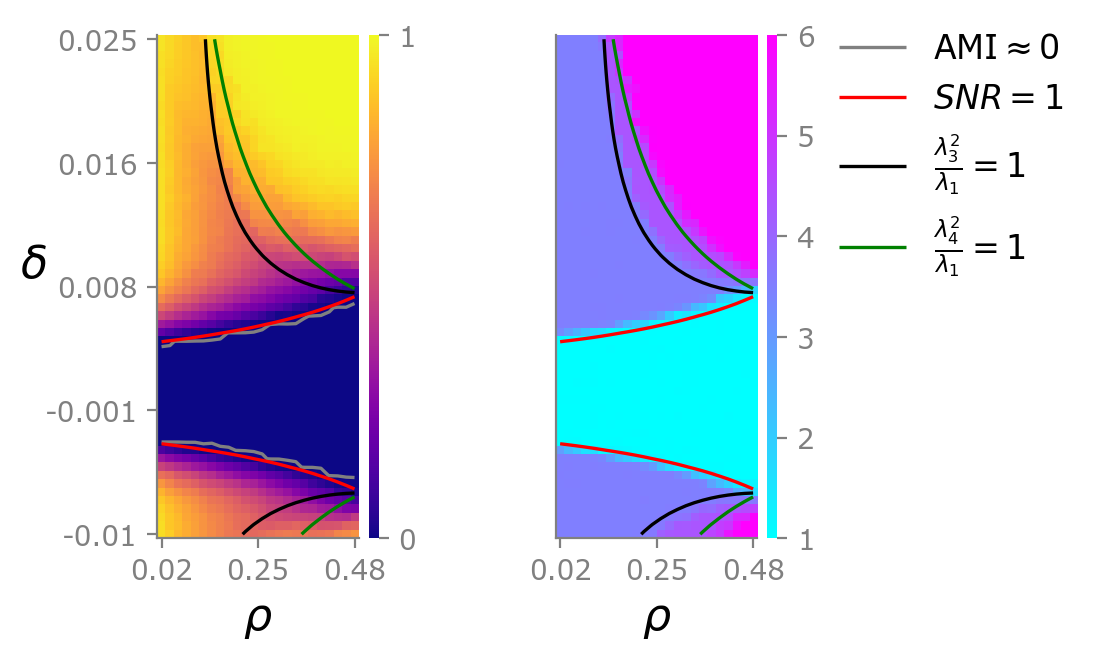

In [14]:
# figsize (width, height) with inch, 1 inch = 72 pt
fig = plt.figure(figsize=(4, 4))
widths = [3, 3]
heights = [3]
spec5 = fig.add_gridspec(ncols=2, nrows=1, width_ratios=widths, height_ratios=heights)
row = 0
col = 0
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["plasma"]
zcenter = 0.5
plot_subami = color_imshow_2d(plot_rhos, plot_zs, sub_ami, z_center=zcenter, title="", xlabel=r'$\rho$', ylabel=r'$\delta$', cmap=cmap, ax=ax, fig=fig, ytickprecision=3)
# ax.set_xlabel(r'$\rho$', fontsize=20)
handels = []
handels += contour_data(plot_subami, ax, levels=[1e-3], fmt={1e-3: r'AMI$\simeq$0'}, color='gray', inline=False)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
handels += contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)

handels += contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
handels += contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)
row = 0
col = 1
ax = fig.add_subplot(spec5[row, col])
cmap = mpl.colormaps["cool"]
plot_subnumgroup = color_imshow_2d(plot_rhos, plot_zs, sub_num_group, z_center=3, title="", xlabel=r'$\rho$', ylabel=r'', cmap=cmap, ax=ax, fig=fig,
                                   vmax=6, set_yticks=False, ytickprecision=3)
plot_l4overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 3]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_l3overl1 = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 2]**2/lambdas[:, 0], z_center=1, return_gridz=True)
plot_snrm = color_imshow_2d(plot_rhos, plot_zs, lambdas[:, 1]**2/lambdas[:, 0], z_center=1, return_gridz=True)
contour_data(plot_snrm, ax, levels=[1], fmt={1: r'$SNR=1$'}, color='red', inline=False)
contour_data(plot_l4overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_4^2}{\lambda_1}=1$'}, color='green', inline=False)
contour_data(plot_l3overl1, ax, levels=[1], fmt={1: r'$\frac{\lambda_3^2}{\lambda_1}=1$'}, color='black', inline=False)
lgd = fig.legend(handels, [r'AMI$\approx$0', r'$SNR=1$', r'$\frac{\lambda_3^2}{\lambda_1}=1$', r'$\frac{\lambda_4^2}{\lambda_1}=1$'], 
           loc=2, bbox_to_anchor=(0.94, 0.85),  fontsize=12, markerscale=2, frameon=False)
plt.subplots_adjust(wspace=0.8)
save_path = "./_Figure/Minority/" + "FigureMinorityAMISNR_" + f'Z_s{Z_s}Z_b{Z_b}d_{d}' + ".pdf"
# plt.tight_layout()
plt.savefig(save_path, dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

# Test

C:\Users\24391\AppData\Local\Temp\ipykernel_6428\1746592789.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  ax[0].imshow(img, cmap=cm.get_cmap("berlin"))


ValueError: 'berlin' is not a valid value for name; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm

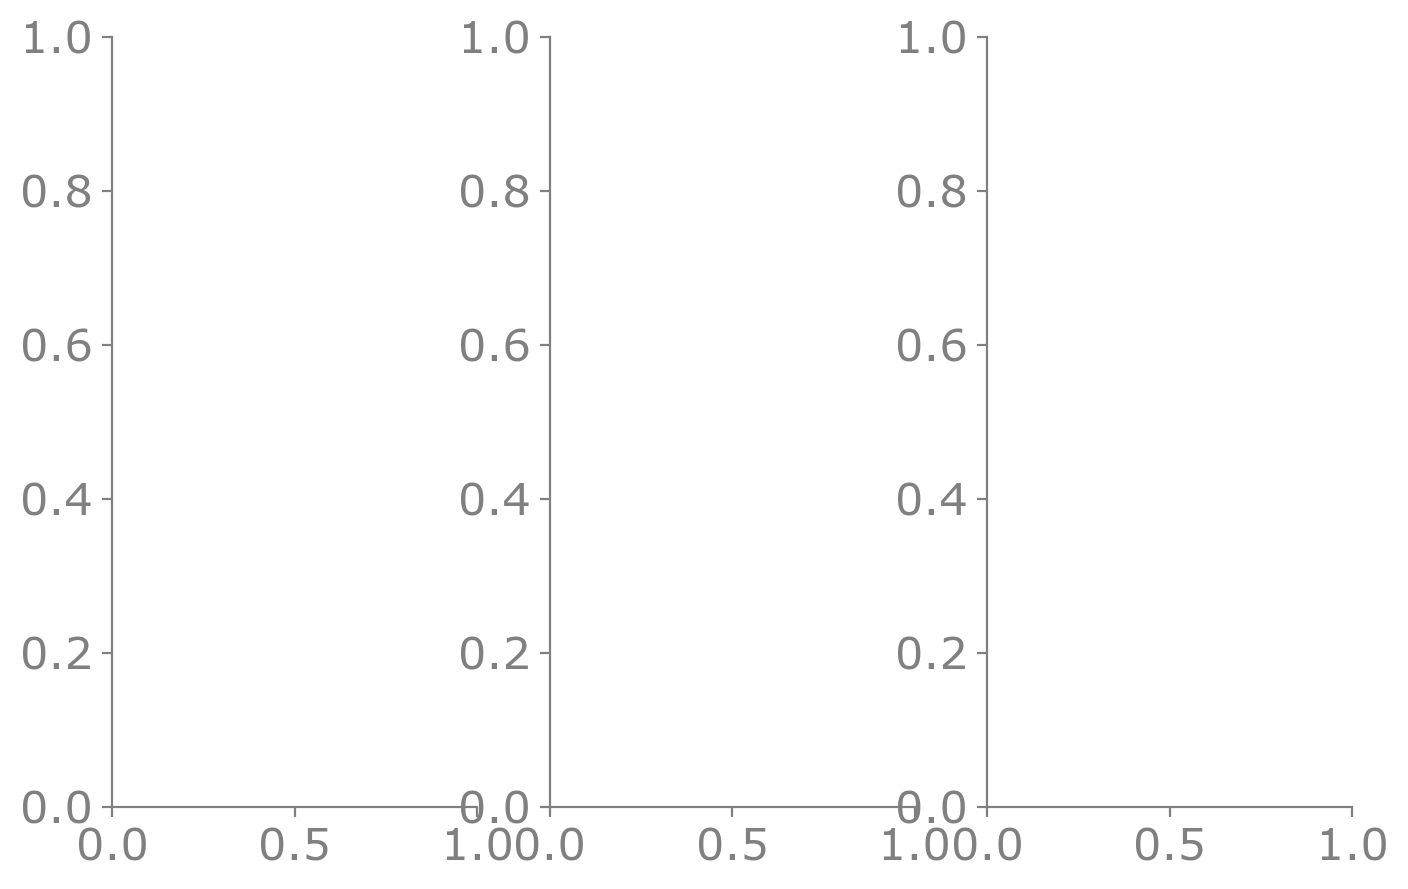

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

vals = np.linspace(-5, 5, 100)
x, y = np.meshgrid(vals, vals)
img = np.sin(x*y)

_, ax = plt.subplots(1, 3)
ax[0].imshow(img, cmap=cm.get_cmap("berlin"))
ax[1].imshow(img, cmap=plt.cm.managua)
ax[2].imshow(img, cmap=plt.cm.vanimo)

In [14]:
np.setdiff1d(np.around(np.linspace(0.02, 0.38, 19), 2), np.array([0, 0.5]))

array([0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 , 0.22,
       0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38])

In [16]:
min_delta = 0  # only consider assortative case
max_delta = 0.00351
np.setdiff1d(np.around(np.linspace(min_delta, max_delta, 25), 5), np.array([0]))

array([0.00015, 0.00029, 0.00044, 0.00058, 0.00073, 0.00088, 0.00102,
       0.00117, 0.00132, 0.00146, 0.00161, 0.00176, 0.0019 , 0.00205,
       0.00219, 0.00234, 0.00249, 0.00263, 0.00278, 0.00292, 0.00307,
       0.00322, 0.00336, 0.00351])